# Salary Predictions Based on Job Descriptions

# DEFINE

### ---- 1 Defining the problem ----

How can we use job postings to predict salaries? 

Using data from historical job postings we will train a model to predict salaries.  This will allow recruiters to make more informed decisions when making and negotiating job offers. 

In [1]:
# Environment & Core Libraries
%pip install seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings for Portfolio
%matplotlib inline
plt.style.use('bmh') 
pd.options.display.max_columns = None
pd.options.display.precision = 2 

# Project Metadata
__author__ = "Kevin Moldovan"
print(f"Libraries loaded. Environment ready for {__author__}'s RevOps Analysis.")



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Libraries loaded. Environment ready for Kevin Moldovan's RevOps Analysis.


In [2]:
# Data viz settings

def plot_target_distribution(df):
    """Overall look at the Salary column."""
    plt.figure(figsize=(12, 5))
    sns.histplot(df['salary'], kde=True, color='teal')
    plt.title('Overall Salary Distribution (Target Variable)', fontsize=16, fontweight='bold')
    plt.xlabel('Salary (k)')
    plt.show()

def plot_categorical_analysis(df, column):
    """Side-by-side: Count and Salary for Categories (Industry, Job Type, etc)."""
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Count
    sns.countplot(data=df, x=column, order=df[column].value_counts().index, 
                  hue=column, legend=False, palette='crest', ax=ax[0])
    ax[0].set_title(f'Count of {column}', fontsize=14, fontweight='bold')
    ax[0].tick_params(axis='x', rotation=45)

    # 2. Distribution vs Salary
    mean_order = df.groupby(column)['salary'].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x=column, y='salary', order=mean_order, 
                hue=column, legend=False, palette='viridis', ax=ax[1])
    ax[1].set_title(f'Salary vs {column}', fontsize=14, fontweight='bold')
    ax[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

def plot_numerical_analysis(df, column):
    """Joint Plot for Numbers (Years Experience, Distance from City)."""
    # Hexbin handles density much better than a standard scatter plot
    grid = sns.jointplot(data=df.sample(5000), x=column, y='salary', 
                         kind='hex', cmap='YlGnBu', height=8)
    grid.fig.suptitle(f'Density: {column} vs. Salary', fontsize=16, fontweight='bold', y=1.03)
    grid.set_axis_labels(column, 'Salary (k)', fontsize=12)
    plt.show()


## DISCOVER

### ---- 2 Loading the data ----

In [3]:
#load the data into a Pandas dataframe
train_features = pd.read_csv('data/train_features.csv')
train_salaries = pd.read_csv('data/train_salaries.csv')
test_features= pd.read_csv('data/test_features.csv')
print('CSVs loaded')

CSVs loaded


In [4]:
#only for google colab - loading data
train_features = pd.read_csv('data/train_features.csv')
train_salaries = pd.read_csv('data/train_salaries.csv')
test_features = pd.read_csv('data/test_features.csv')
print('CSVs loaded')

CSVs loaded


### ---- 3 Clean the data ---- 
Looking for duplicate data, invalid data (e.g. salaries <=0), or corrupt data and remove it

In [5]:
train_features.head(10)

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis
0,JOB1362684407687,COMP37,CFO,MASTERS,MATH,HEALTH,10,83
1,JOB1362684407688,COMP19,CEO,HIGH_SCHOOL,NONE,WEB,3,73
2,JOB1362684407689,COMP52,VICE_PRESIDENT,DOCTORAL,PHYSICS,HEALTH,10,38
3,JOB1362684407690,COMP38,MANAGER,DOCTORAL,CHEMISTRY,AUTO,8,17
4,JOB1362684407691,COMP7,VICE_PRESIDENT,BACHELORS,PHYSICS,FINANCE,8,16
5,JOB1362684407692,COMP15,MANAGER,DOCTORAL,COMPSCI,FINANCE,2,31
6,JOB1362684407693,COMP15,CFO,NONE,NONE,HEALTH,23,24
7,JOB1362684407694,COMP24,JUNIOR,BACHELORS,CHEMISTRY,EDUCATION,9,70
8,JOB1362684407695,COMP20,JANITOR,HIGH_SCHOOL,NONE,EDUCATION,1,54
9,JOB1362684407696,COMP41,VICE_PRESIDENT,BACHELORS,CHEMISTRY,AUTO,17,68


In [6]:
test_features.head(10)

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis
0,JOB1362685407687,COMP33,MANAGER,HIGH_SCHOOL,NONE,HEALTH,22,73
1,JOB1362685407688,COMP13,JUNIOR,NONE,NONE,AUTO,20,47
2,JOB1362685407689,COMP10,CTO,MASTERS,BIOLOGY,HEALTH,17,9
3,JOB1362685407690,COMP21,MANAGER,HIGH_SCHOOL,NONE,OIL,14,96
4,JOB1362685407691,COMP36,JUNIOR,DOCTORAL,BIOLOGY,OIL,10,44
5,JOB1362685407692,COMP40,CTO,MASTERS,COMPSCI,FINANCE,6,23
6,JOB1362685407693,COMP32,SENIOR,MASTERS,COMPSCI,SERVICE,6,32
7,JOB1362685407694,COMP11,CEO,BACHELORS,BIOLOGY,SERVICE,9,73
8,JOB1362685407695,COMP39,MANAGER,DOCTORAL,PHYSICS,HEALTH,6,78
9,JOB1362685407696,COMP22,VICE_PRESIDENT,NONE,NONE,AUTO,23,97


In [7]:
train_salaries.head(10)

,jobId,salary
0,JOB1362684407687,130
1,JOB1362684407688,101
2,JOB1362684407689,137
3,JOB1362684407690,142
4,JOB1362684407691,163
5,JOB1362684407692,113
6,JOB1362684407693,178
7,JOB1362684407694,73
8,JOB1362684407695,31
9,JOB1362684407696,104


In [8]:
train_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   jobId                1000000 non-null  str  
 1   companyId            1000000 non-null  str  
 2   jobType              1000000 non-null  str  
 3   degree               1000000 non-null  str  
 4   major                1000000 non-null  str  
 5   industry             1000000 non-null  str  
 6   yearsExperience      1000000 non-null  int64
 7   milesFromMetropolis  1000000 non-null  int64
dtypes: int64(2), str(6)
memory usage: 61.0 MB


In [9]:
test_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   jobId                1000000 non-null  str  
 1   companyId            1000000 non-null  str  
 2   jobType              1000000 non-null  str  
 3   degree               1000000 non-null  str  
 4   major                1000000 non-null  str  
 5   industry             1000000 non-null  str  
 6   yearsExperience      1000000 non-null  int64
 7   milesFromMetropolis  1000000 non-null  int64
dtypes: int64(2), str(6)
memory usage: 61.0 MB


In [10]:
train_salaries.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   jobId   1000000 non-null  str  
 1   salary  1000000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 15.3 MB


#### Checking for duplicate data

In [11]:
print('train_features duplicates: ', train_features.duplicated().sum())
print('train_salaries duplicates: ', train_salaries.duplicated().sum())
print('test_features  duplicates: ', test_features.duplicated().sum())

train_features duplicates:  0
train_salaries duplicates:  0
test_features  duplicates:  0


#### Finding Corrupt Data

In [12]:
#Looking for invalid/corrupt data 
print(train_features.isnull().sum())
print(train_salaries.isnull().sum())
print(test_features.isnull().sum())

jobId                  0
companyId              0
jobType                0
degree                 0
major                  0
industry               0
yearsExperience        0
milesFromMetropolis    0
dtype: int64
jobId     0
salary    0
dtype: int64
jobId                  0
companyId              0
jobType                0
degree                 0
major                  0
industry               0
yearsExperience        0
milesFromMetropolis    0
dtype: int64


In [13]:
#Merging Train and Target DFs
train_df = pd.merge(train_features, train_salaries, on='jobId')

In [14]:
# Checking data shape
print(f"Original dataset size: {train_df.shape[0]}")

# Filtering out corrupt or 'impossible' salary data
train_df = train_df[train_df.salary > 0].copy()

print(f"Cleaned dataset size: {train_df.shape[0]}")
print(f"Number of rows removed: {1000000 - train_df.shape[0]}")

Original dataset size: 1000000
Cleaned dataset size: 999995
Number of rows removed: 5


In [15]:
# Verify the top 5 and the column types
display(train_df.head())
print(train_df.info())

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis,salary
0,JOB1362684407687,COMP37,CFO,MASTERS,MATH,HEALTH,10,83,130
1,JOB1362684407688,COMP19,CEO,HIGH_SCHOOL,NONE,WEB,3,73,101
2,JOB1362684407689,COMP52,VICE_PRESIDENT,DOCTORAL,PHYSICS,HEALTH,10,38,137
3,JOB1362684407690,COMP38,MANAGER,DOCTORAL,CHEMISTRY,AUTO,8,17,142
4,JOB1362684407691,COMP7,VICE_PRESIDENT,BACHELORS,PHYSICS,FINANCE,8,16,163


<class 'pandas.DataFrame'>
Index: 999995 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   jobId                999995 non-null  str  
 1   companyId            999995 non-null  str  
 2   jobType              999995 non-null  str  
 3   degree               999995 non-null  str  
 4   major                999995 non-null  str  
 5   industry             999995 non-null  str  
 6   yearsExperience      999995 non-null  int64
 7   milesFromMetropolis  999995 non-null  int64
 8   salary               999995 non-null  int64
dtypes: int64(3), str(6)
memory usage: 76.3 MB
None


In [16]:
#Generating descriptive statistics for for train_df numeric columns
train_df.describe(include = [np.number])

,yearsExperience,milesFromMetropolis,salary
count,999995.00,999995.00,999995.00
mean,11.99,49.53,116.06
std,7.21,28.88,38.72
min,0.00,0.00,17.00
25%,6.00,25.00,88.00
50%,12.00,50.00,114.00
75%,18.00,75.00,141.00
max,24.00,99.00,301.00


In [17]:
#Generating descriptive statistics for train_df categorical columns
train_df.describe(exclude = [np.number])

,jobId,companyId,jobType,degree,major,industry
count,999995,999995,999995,999995,999995,999995
unique,999995,63,8,5,9,7
top,JOB1362684407687,COMP39,SENIOR,HIGH_SCHOOL,NONE,WEB
freq,1,16193,125886,236975,532353,143205


In [18]:
#Generating descriptive statistics for test_feature_df numeric columns
test_features.describe()

,yearsExperience,milesFromMetropolis
count,1000000.00,1000000.00
mean,12.00,49.53
std,7.21,28.89
min,0.00,0.00
25%,6.00,25.00
50%,12.00,50.00
75%,18.00,75.00
max,24.00,99.00


In [19]:
numeric_cols = ['yearsExperience', 'milesFromMetropolis']
categorical_cols = ['jobId', 'companyId', 'jobType', 'degree', 'major', 'industry']

### ---- 4 Explore the data (EDA) ----

In [20]:
#summarize each feature variable 
#summarize the target variable
#look for correlation between each feature and the target
#look for correlation between features

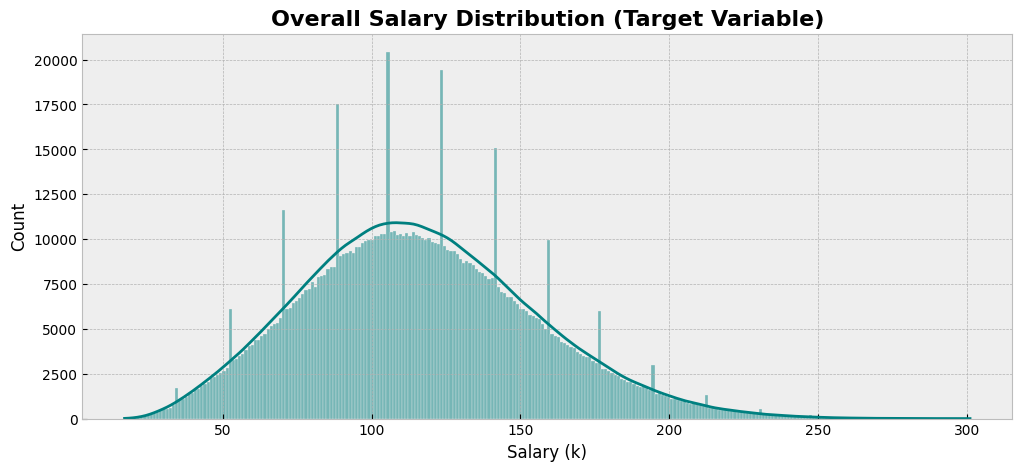

In [21]:
# Overall Target
plot_target_distribution(train_df)



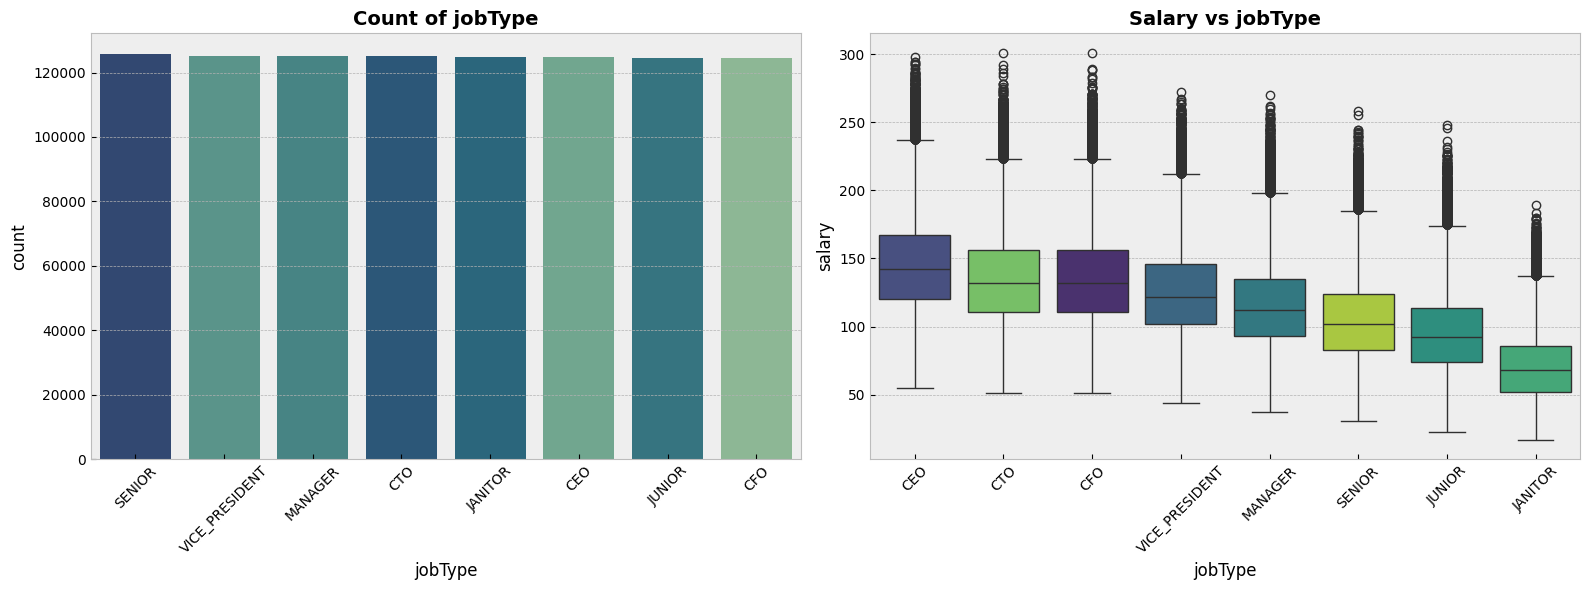

In [22]:
# Categorical Features (Repeat for each)
plot_categorical_analysis(train_df, 'jobType')




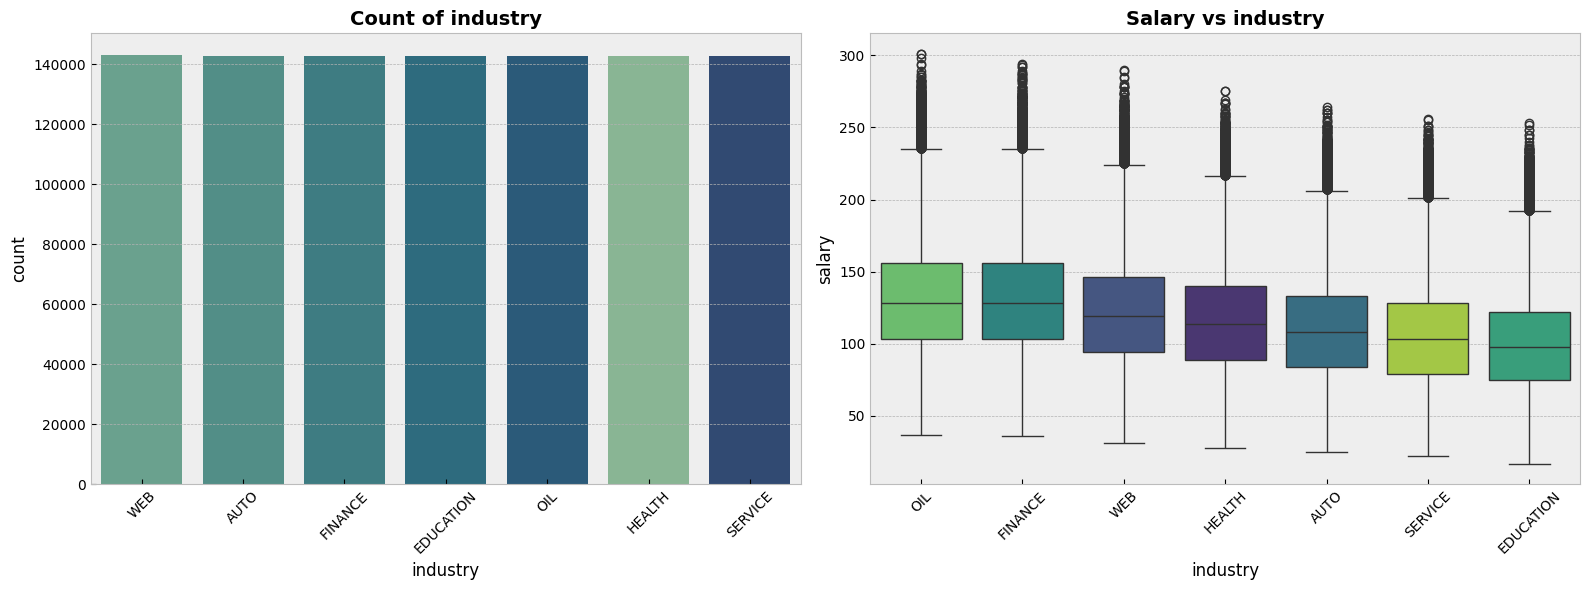

In [23]:
plot_categorical_analysis(train_df, 'industry')


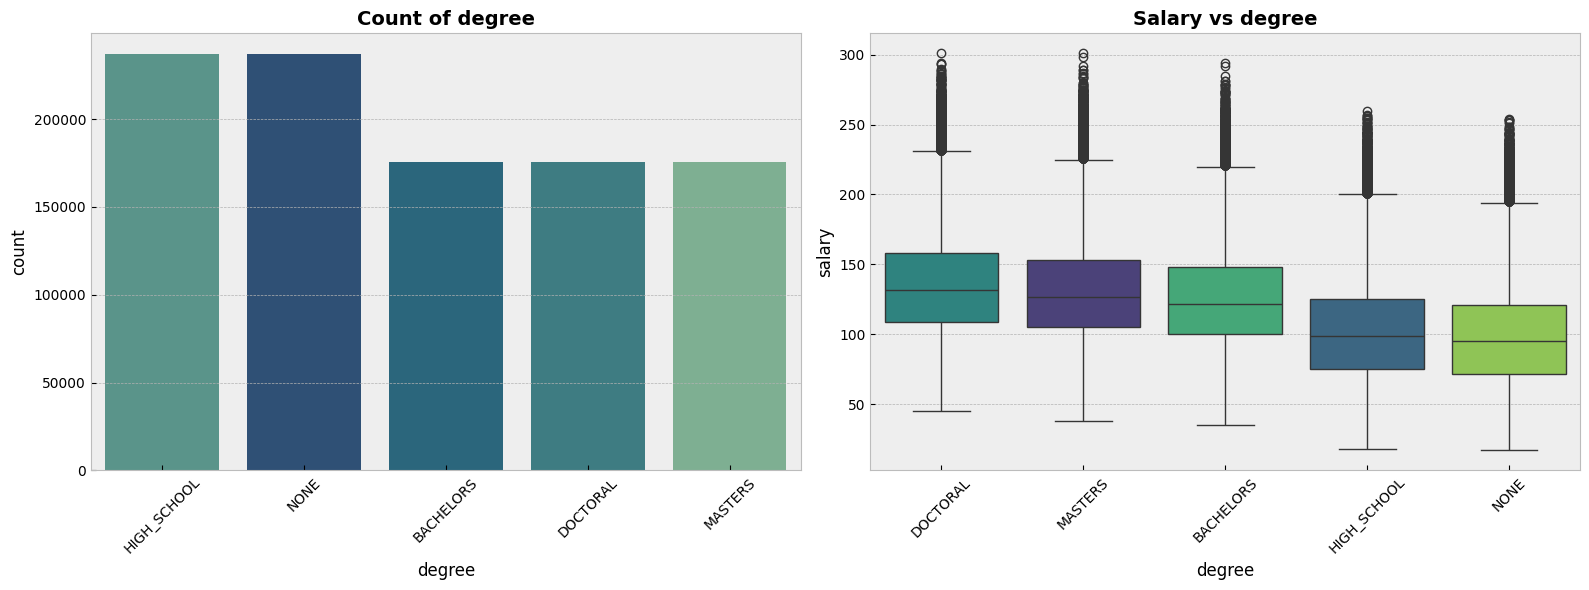

In [24]:
plot_categorical_analysis(train_df, 'degree')


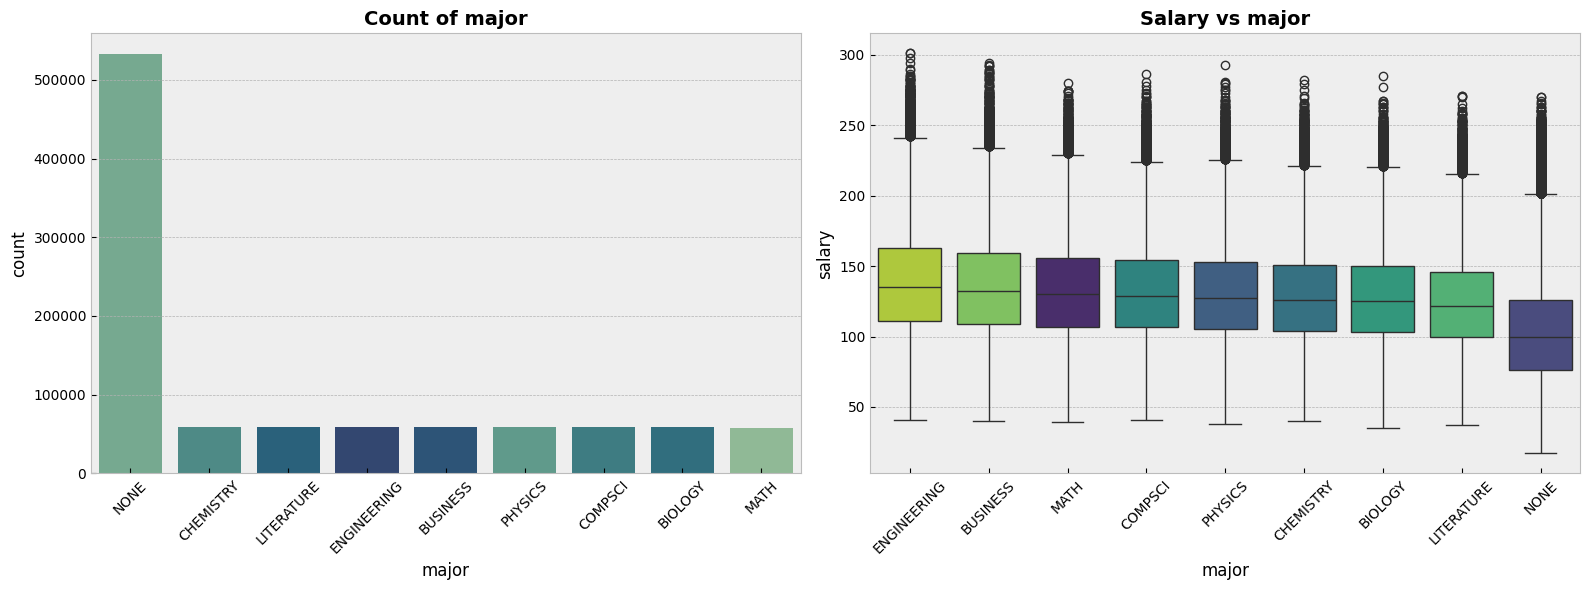

In [25]:
plot_categorical_analysis(train_df, 'major')

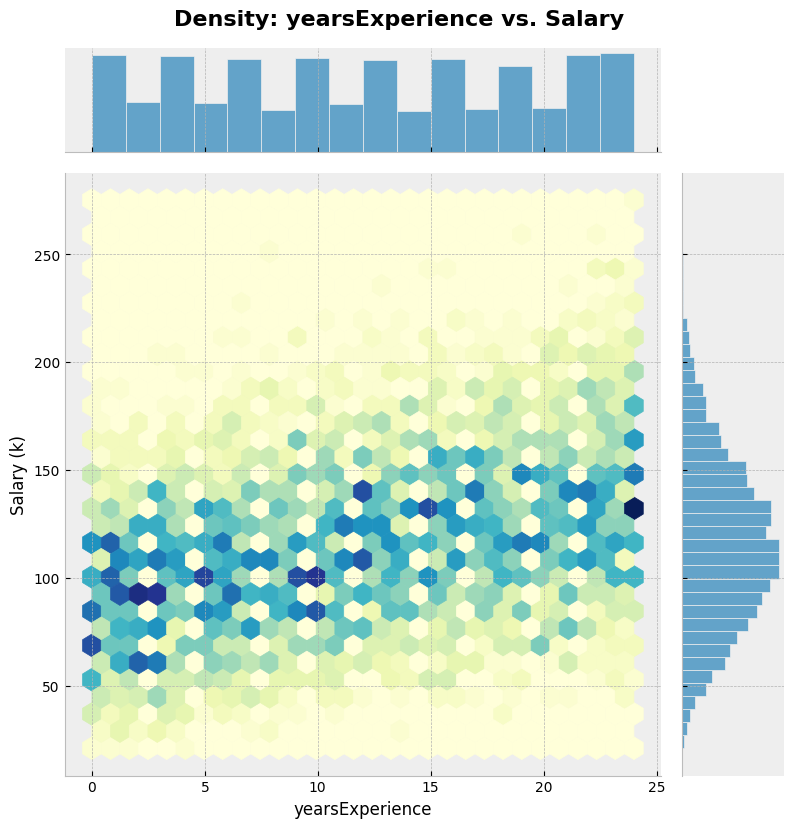

In [26]:
# Numerical Features
plot_numerical_analysis(train_df, 'yearsExperience')

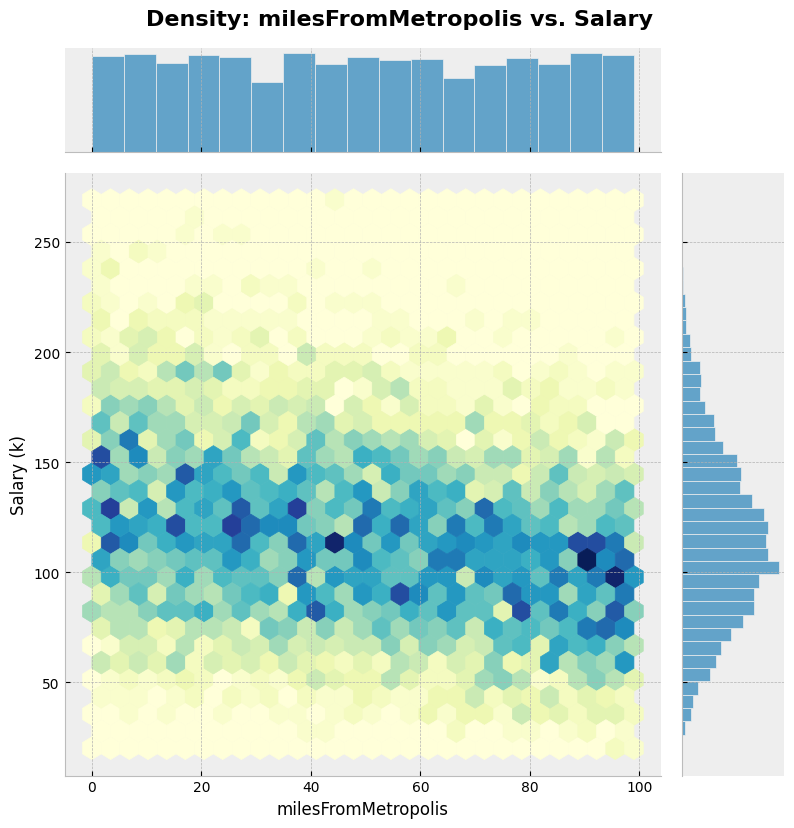

In [27]:

plot_numerical_analysis(train_df, 'milesFromMetropolis')

In [28]:
def plot_categorical_analysis(df, column):
    """
    Shows the 'Count' and 'Salary Distribution' side-by-side for any column.
    """
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. The Count Plot (Your 'category by itself')
    sns.countplot(data=df, x=column, order=df[column].value_counts().index, 
                  hue=column, legend=False, palette='crest', ax=ax[0])
    ax[0].set_title(f'Count of {column}', fontsize=14, fontweight='bold')
    ax[0].tick_params(axis='x', rotation=45)

    # 2. The Salary Distribution (Target Analysis)
    mean_order = df.groupby(column)['salary'].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x=column, y='salary', order=mean_order, 
                hue=column, legend=False, palette='viridis', ax=ax[1])
    ax[1].set_title(f'Salary vs {column}', fontsize=14, fontweight='bold')
    ax[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [29]:
# Separate plot for the overall Salary target
def plot_target_distribution(df):
    plt.figure(figsize=(12, 5))
    sns.histplot(df['salary'], kde=True, color='teal')
    plt.title('Overall Salary Distribution (Target Variable)', fontsize=16, fontweight='bold')
    plt.xlabel('Salary (k)')
    plt.show()

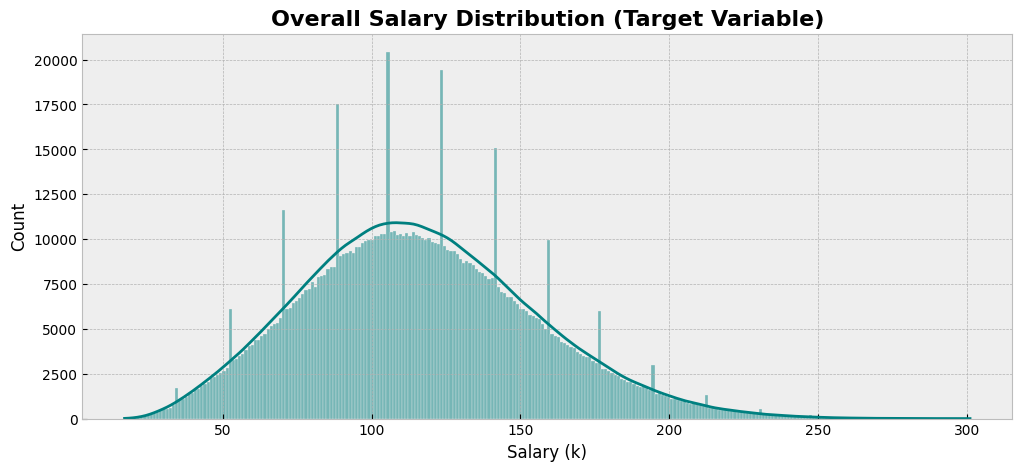

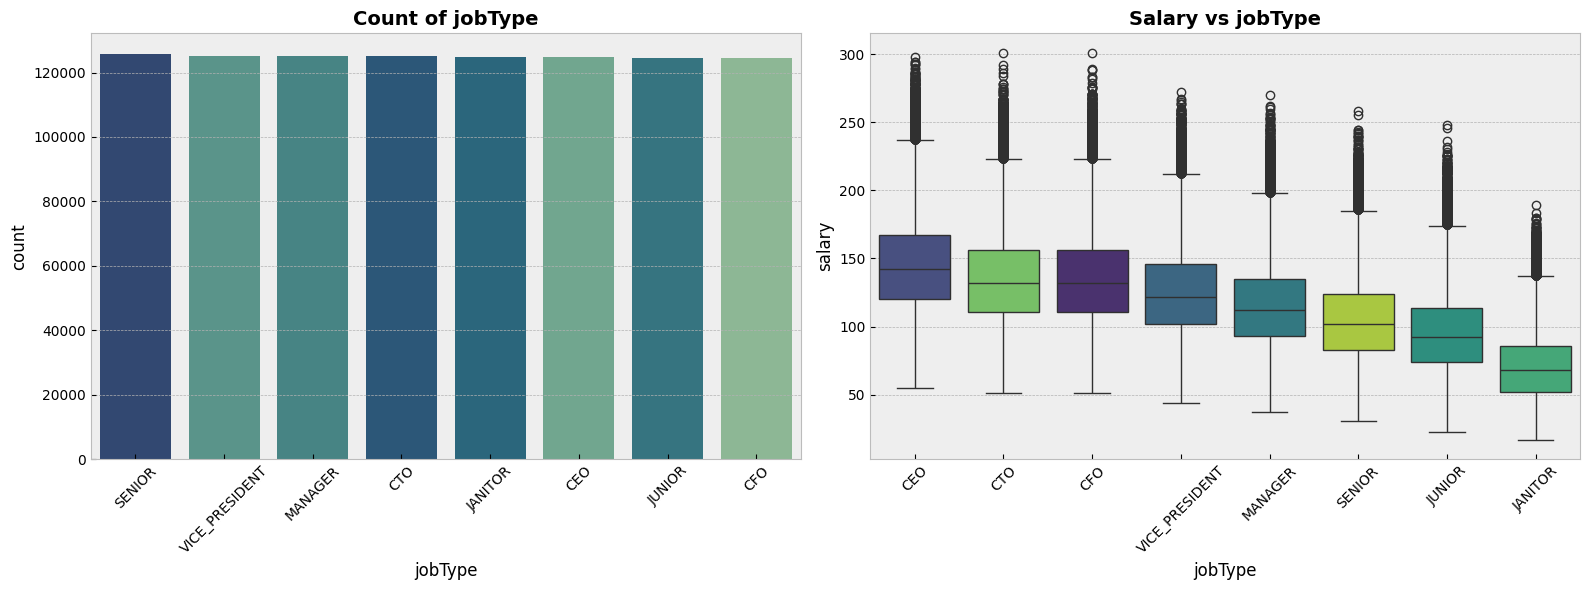

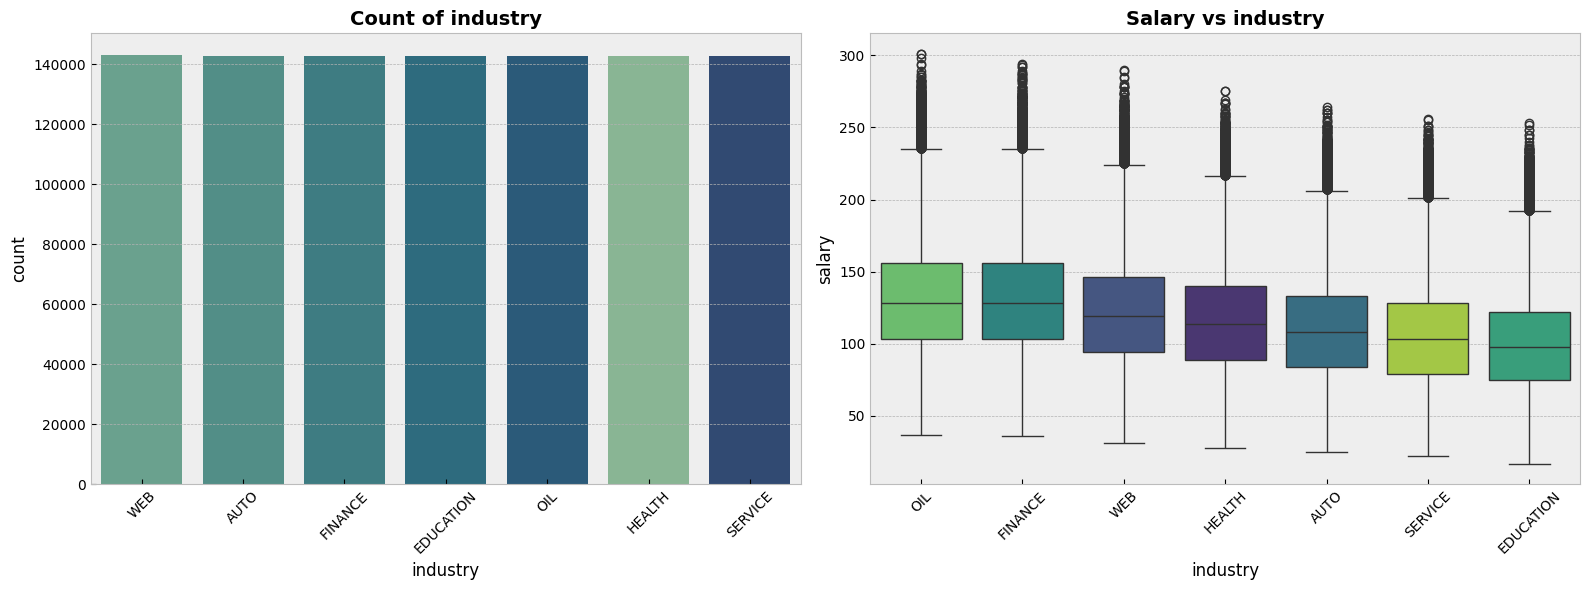

In [30]:
# First, look at the target itself
plot_target_distribution(train_df)

# Then, run the categorical pairs
plot_categorical_analysis(train_df, 'jobType')
plot_categorical_analysis(train_df, 'industry')


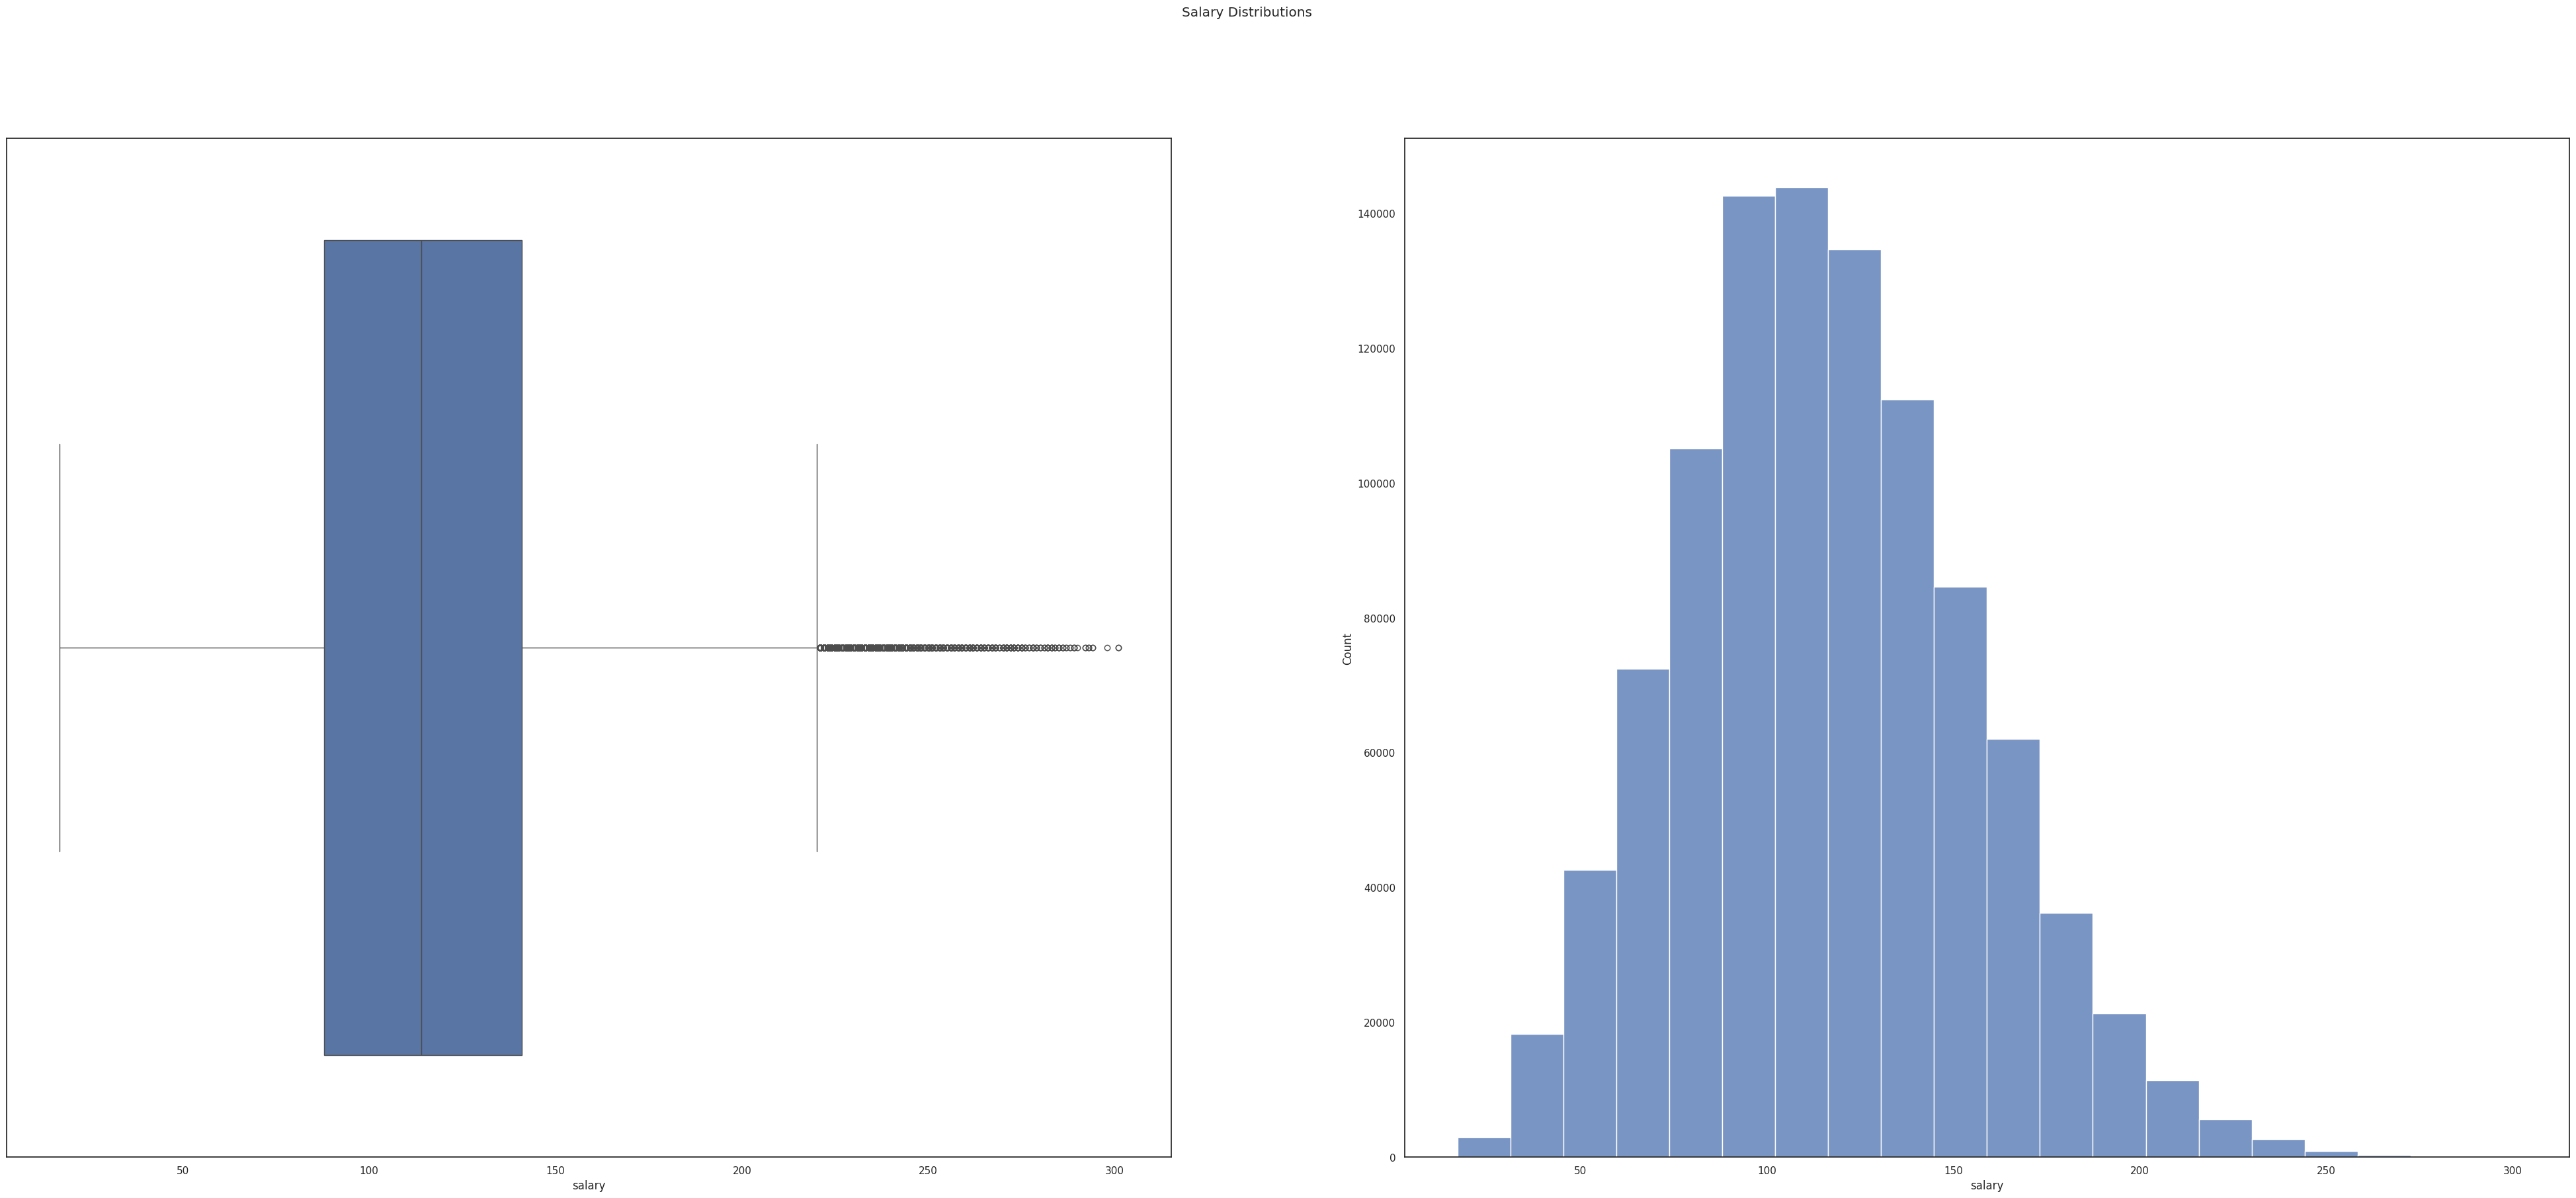

In [31]:
##visualizing salary distributions
sns.set(style='white')
#sns.set_context("poster", font_scale=2)
plt.figure(figsize = (50, 20)) 
plt.subplot(1,2,1)
sns.boxplot(x=train_df.salary) 
plt.subplot(1,2,2)
sns.histplot(x=train_df.salary, bins=20)
plt.suptitle('Salary Distributions') 
plt.show()

The mean salary appears to be close to 110,000 with a few large salaries over 200,000 skewing the distribution to the left

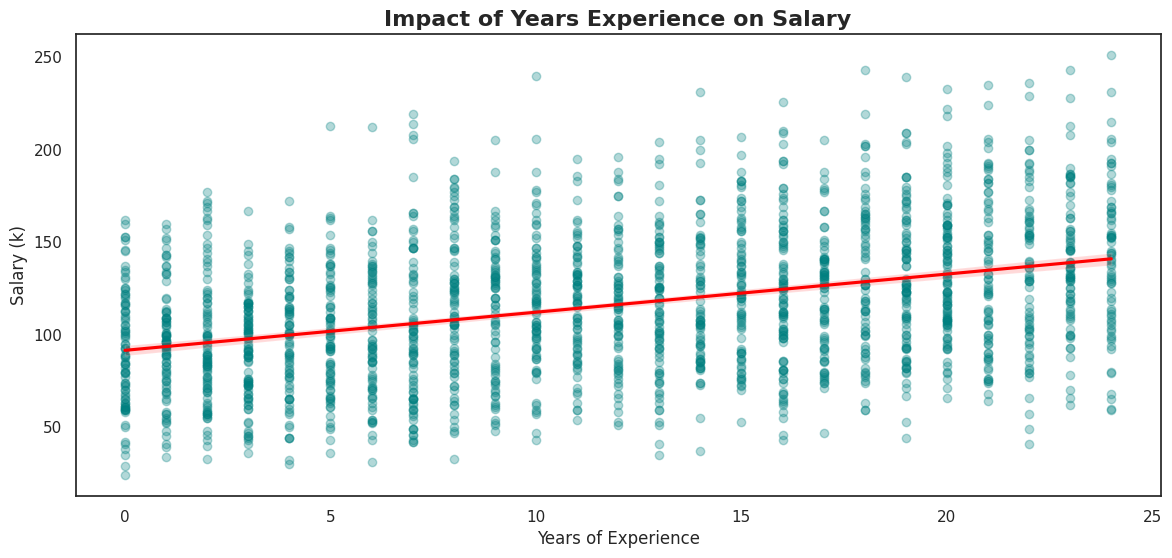

In [32]:
# Modern Visual: Experience vs Salary
plt.figure(figsize=(14, 6))

# Use regplot to show the 'trend line' of how experience affects pay
sns.regplot(data=train_df.sample(2000), x='yearsExperience', y='salary', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Impact of Years Experience on Salary', fontsize=16, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (k)')
plt.show()


In [33]:
#visualizing years of experience vs salary
plot_salary_dist(train_df, 'yearsExperience')

NameError: name 'plot_salary_dist' is not defined

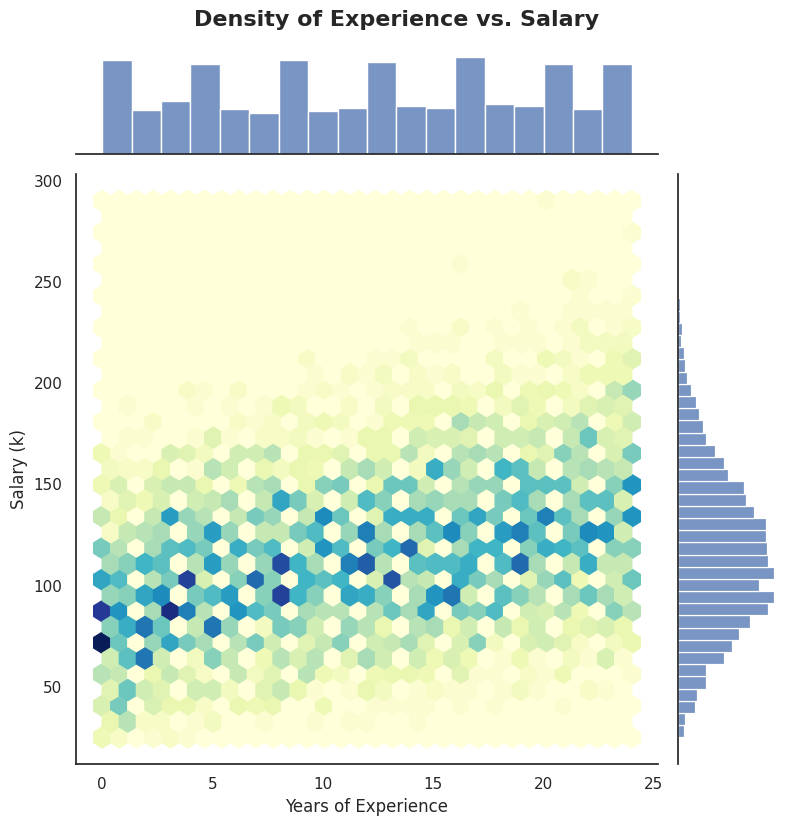

In [34]:
# Modern Visual: Joint Distribution & Trend
# We use a hex plot here because it handles 'crowded' data better than dots
grid = sns.jointplot(data=train_df.sample(5000), x='yearsExperience', y='salary', 
                     kind='hex', cmap='YlGnBu', height=8)

grid.fig.suptitle('Density of Experience vs. Salary', fontsize=16, fontweight='bold', y=1.03)
grid.set_axis_labels('Years of Experience', 'Salary (k)', fontsize=12)

plt.show()


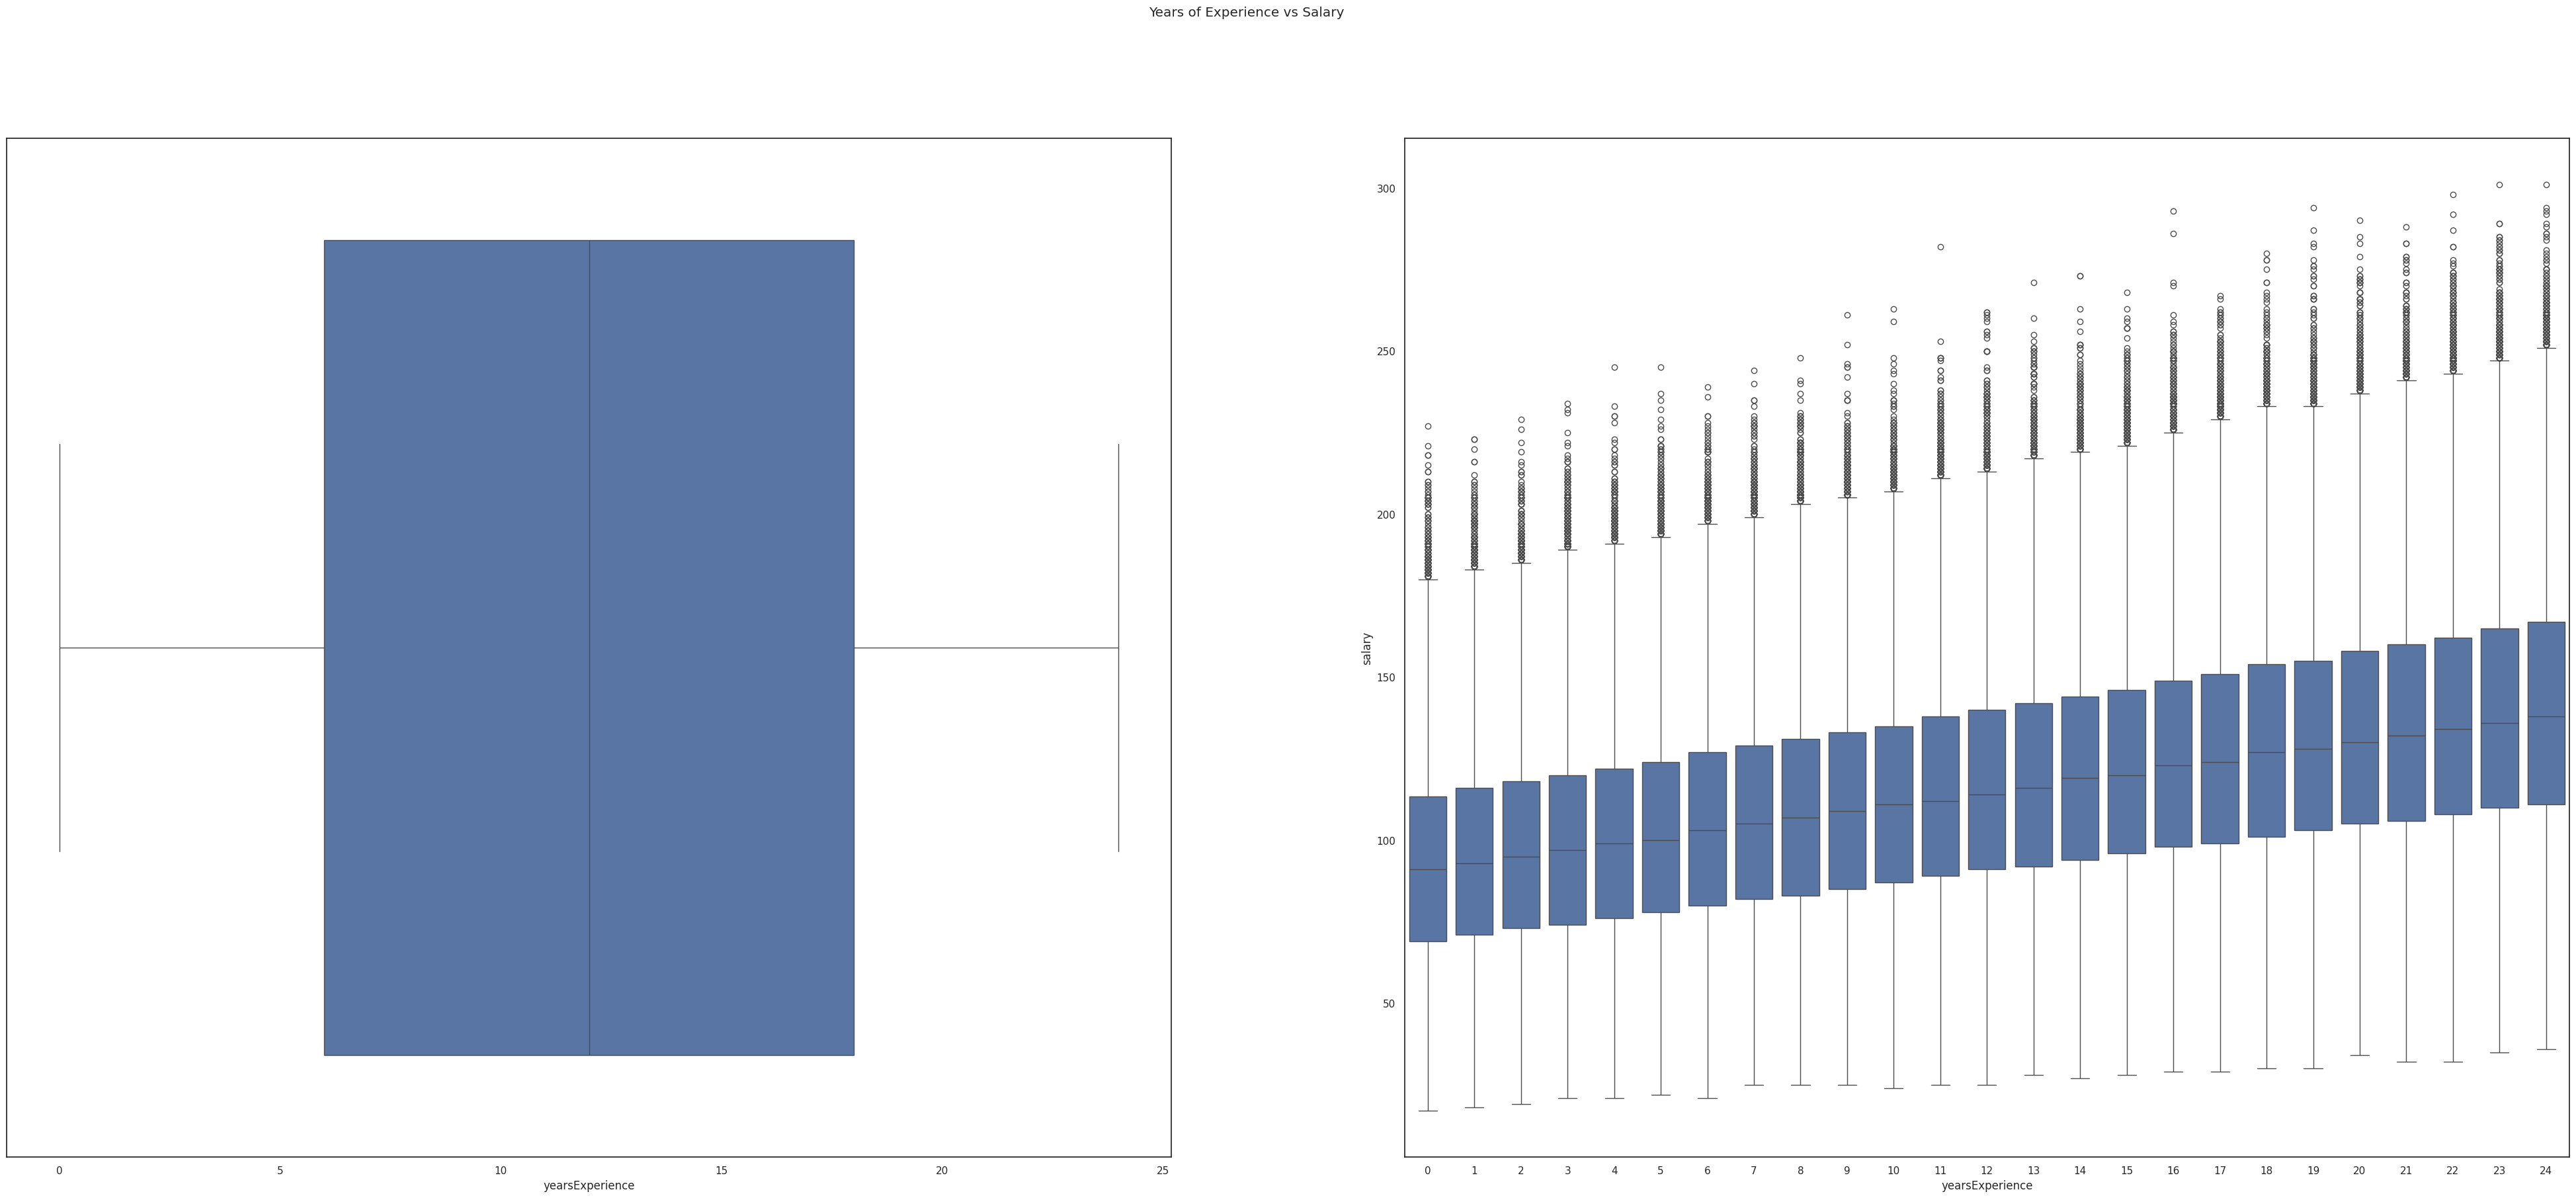

In [35]:
#visualizing years of experience vs salary
#sns.set_context("poster", font_scale=2)
plt.figure(figsize = (50, 20)) 
plt.subplot(1,2,1)
sns.boxplot(x = 'yearsExperience', data = train_df) 
plt.subplot(1,2,2)
sns.boxplot(x = 'yearsExperience', y = 'salary', data = train_df)
plt.suptitle('Years of Experience vs Salary') 
plt.show()

Salary appears to be positively correlated with years of experience.  As years of experience increases, salary increases slightly

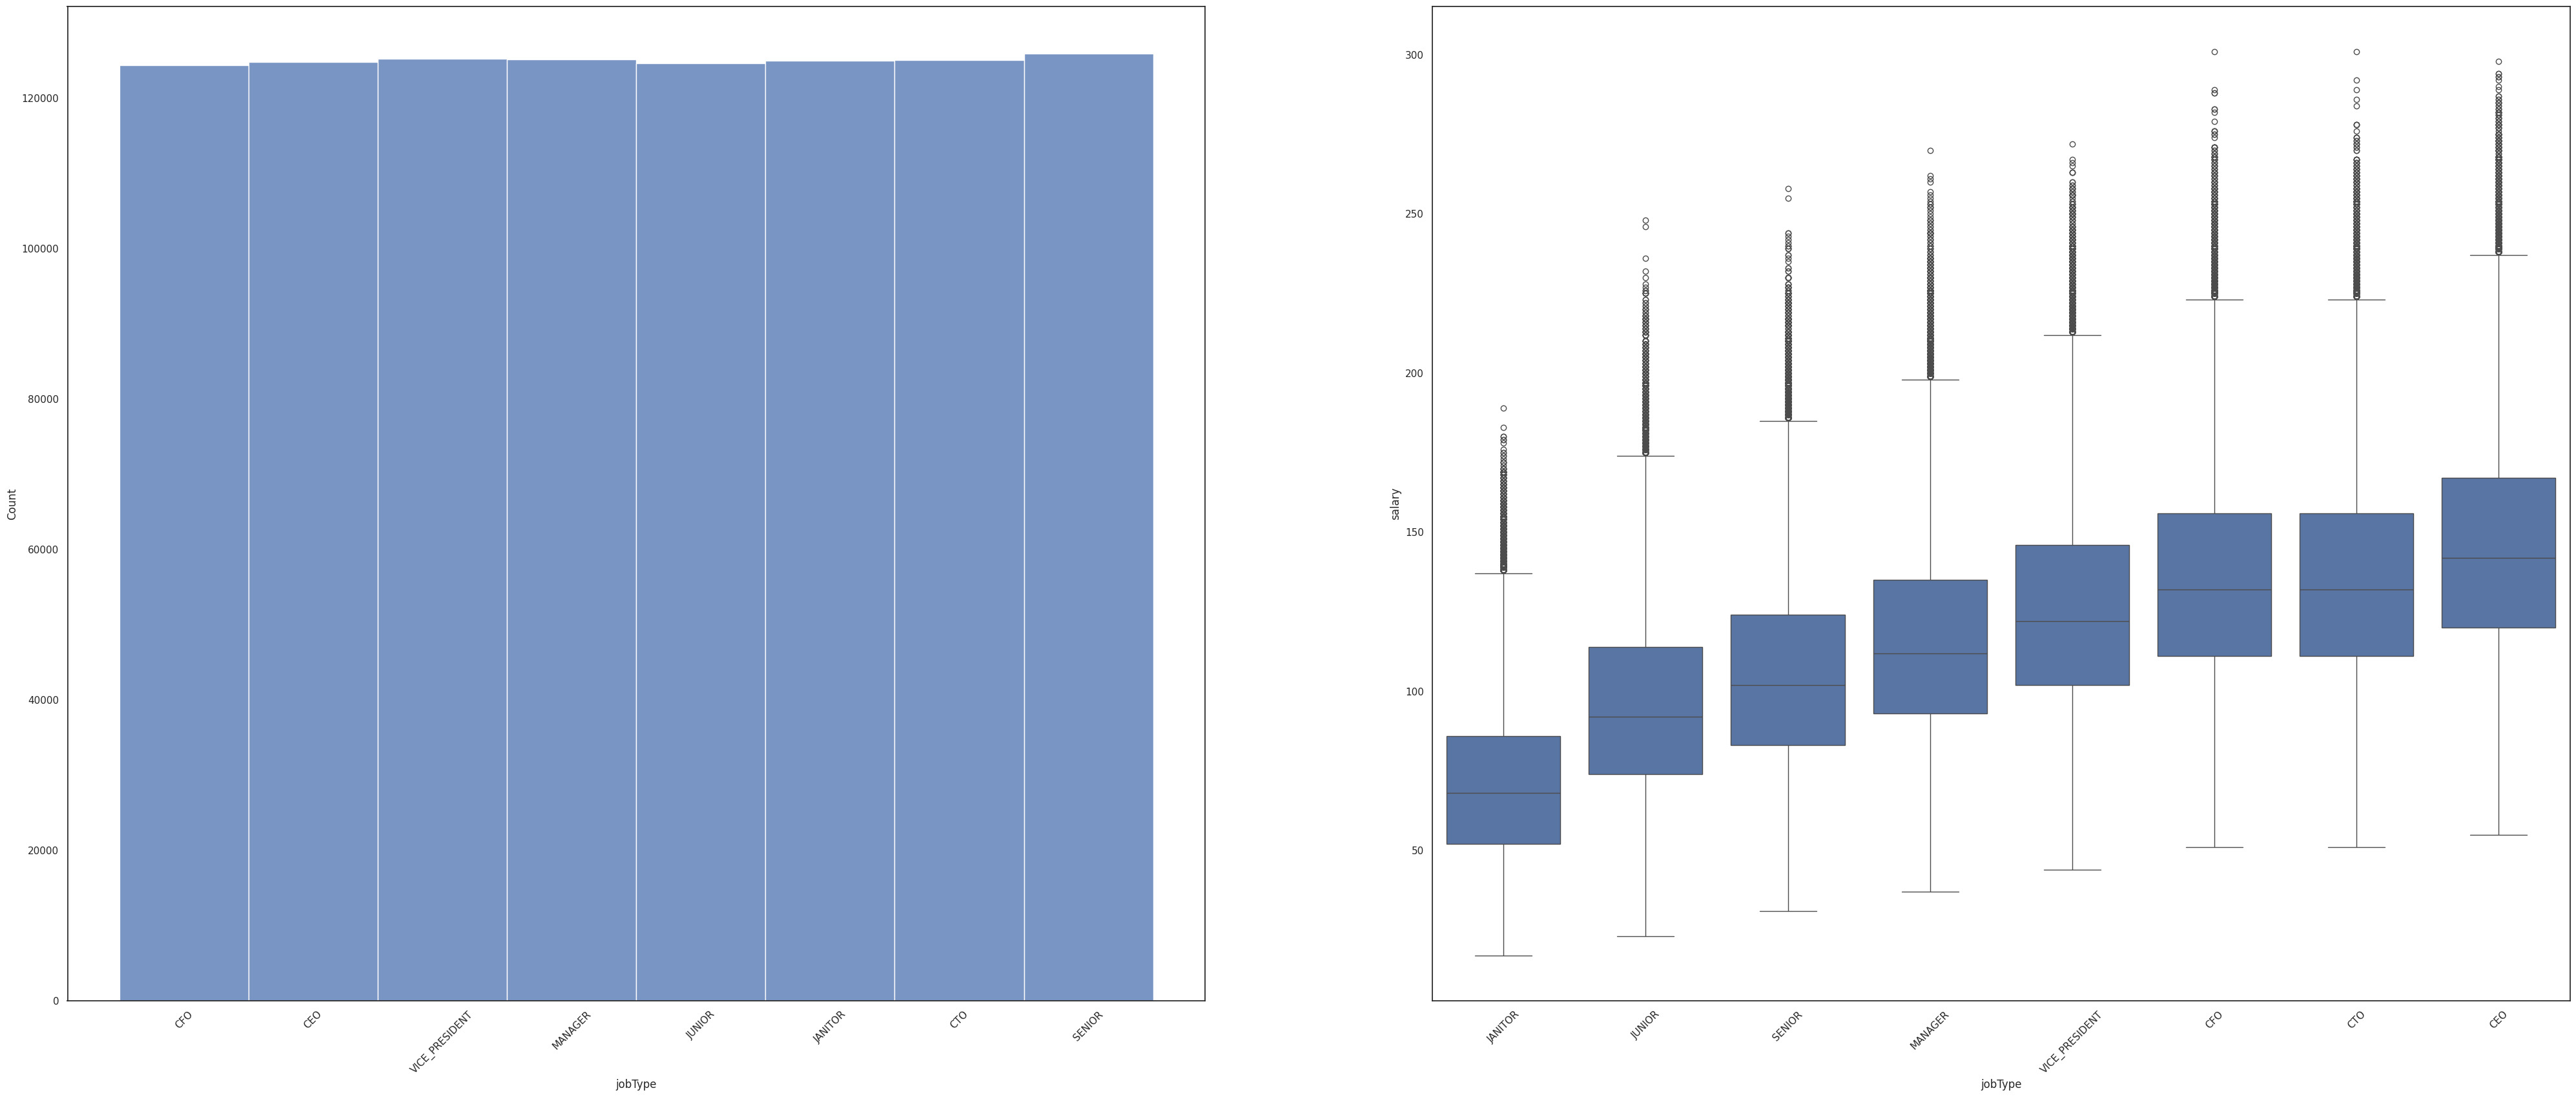

In [36]:
#visualizing job type vs salary
meanorder = train_df.groupby(by=['jobType'])['salary'].mean().sort_values().index
#sns.set_context("poster", font_scale=2)
plt.figure(figsize = (50, 20)) 
plt.subplot(1,2,1)
sns.histplot(x = 'jobType', data = train_df) 
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.boxplot(x='jobType', y='salary', data=train_df, order=meanorder)
plt.xticks(rotation=45)
plt.show()

Salary appears to be positively correlated with job types of advancing career progression

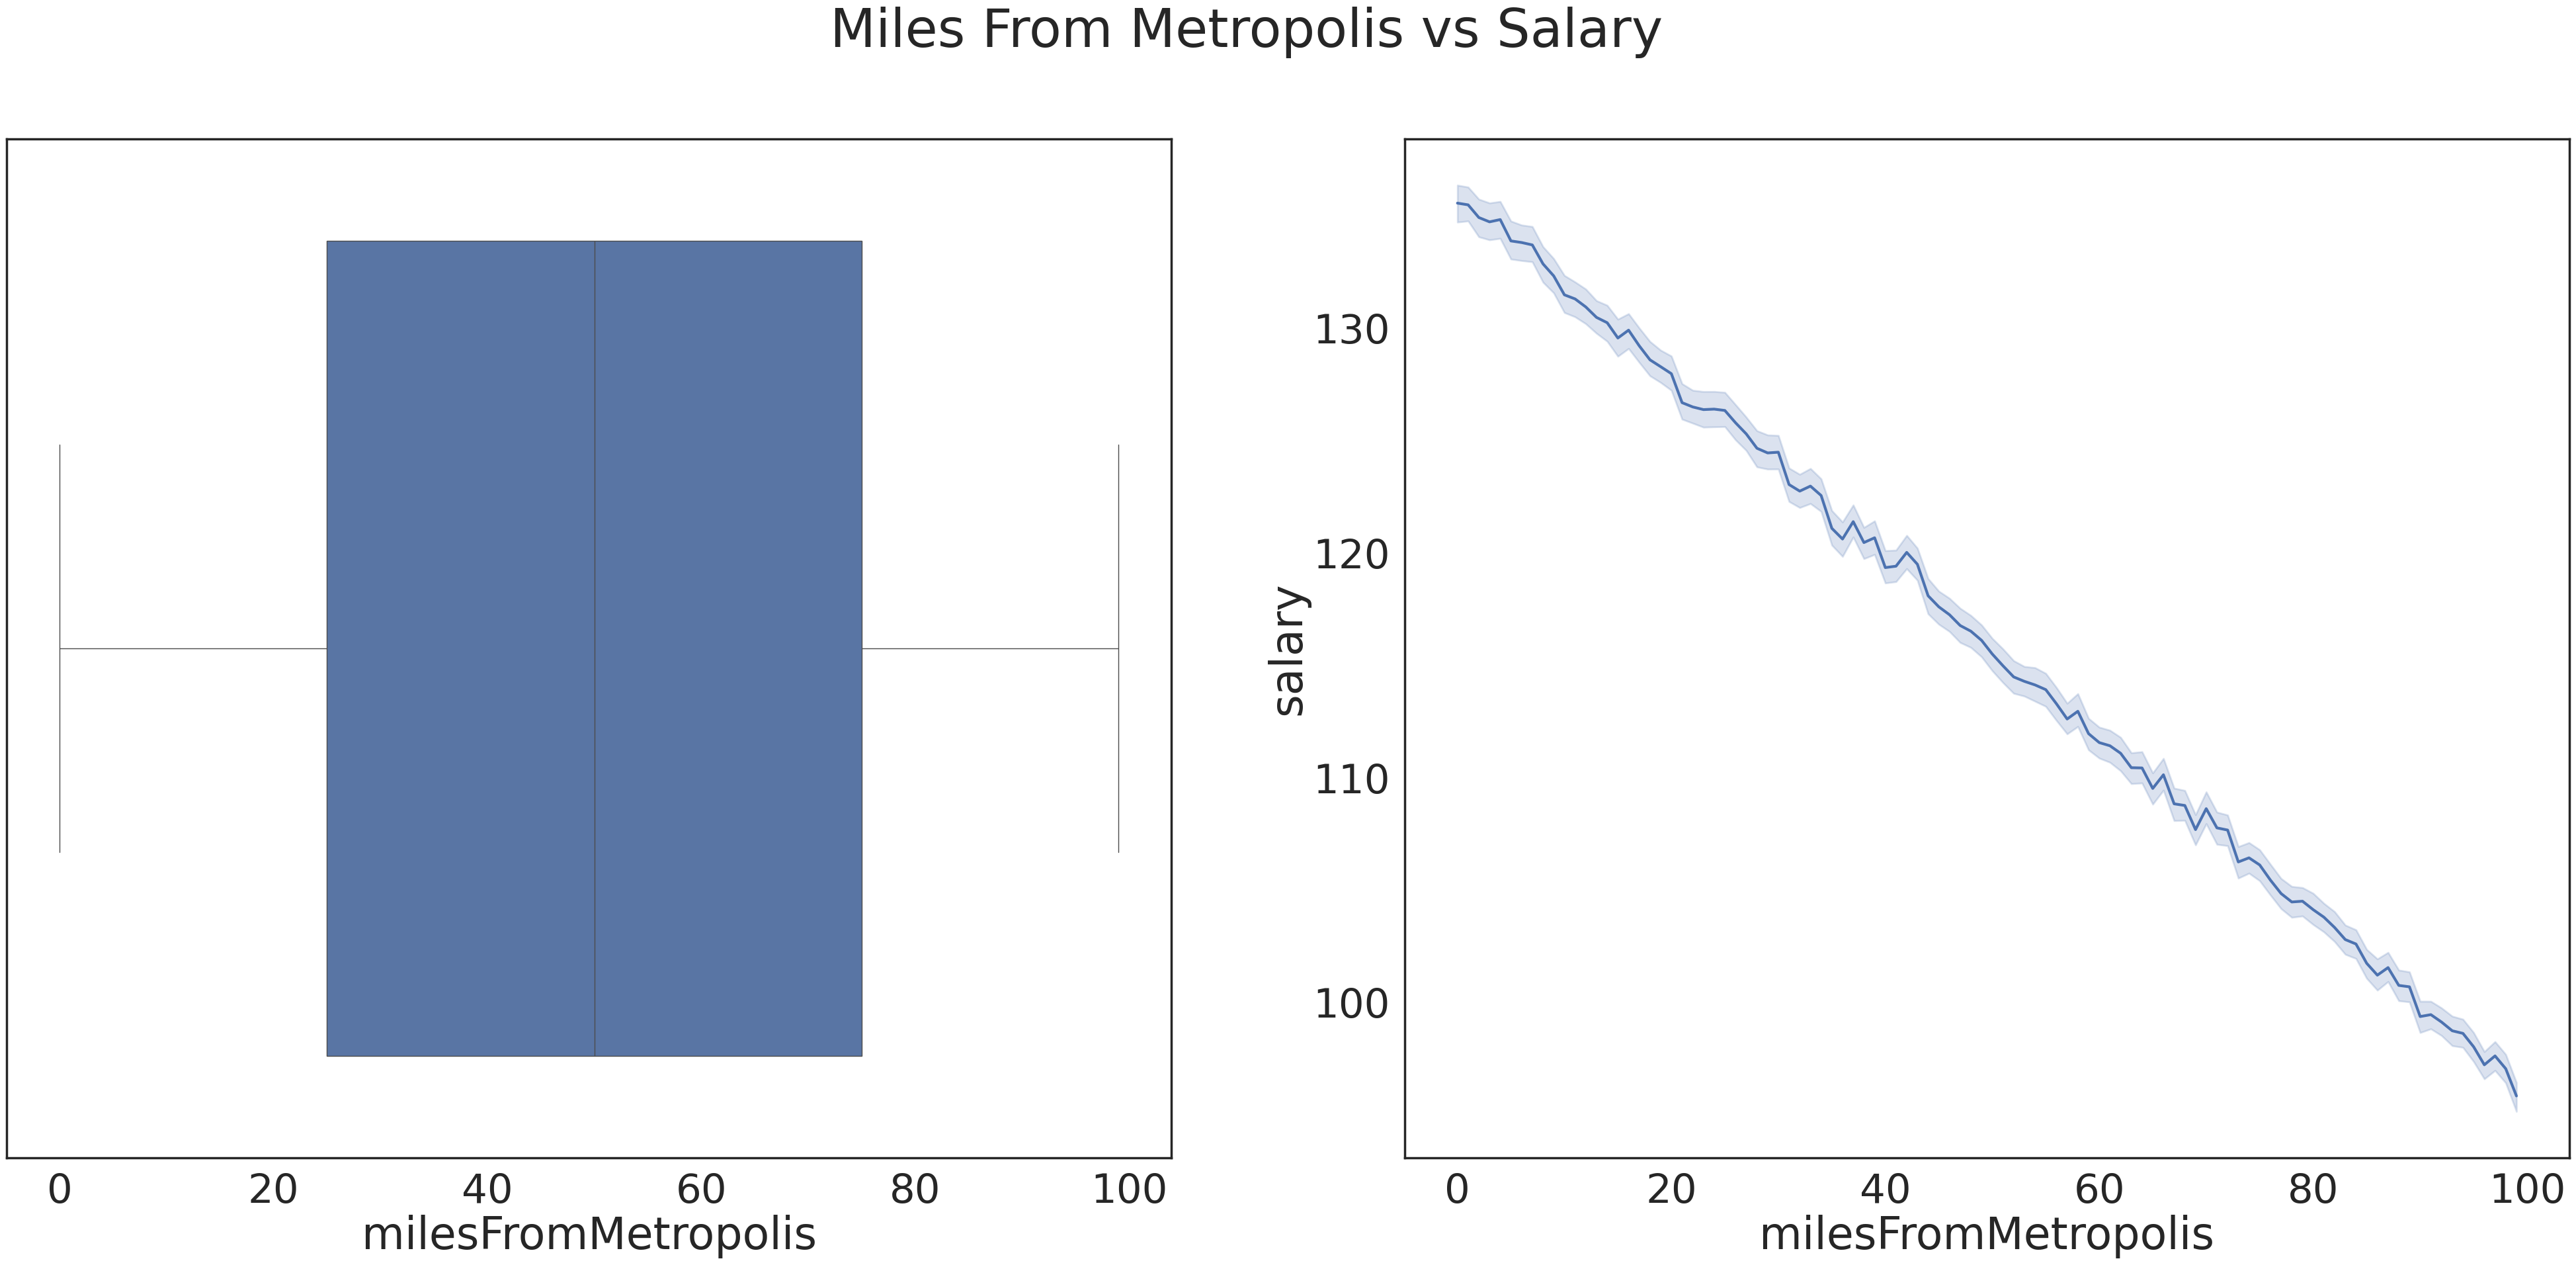

In [ ]:
#visualizing miles from metropolis vs salary
#sns.set_context("poster", font_scale=2)
plt.figure(figsize = (50, 20)) 
plt.subplot(1,2,1)
sns.boxplot(x = 'milesFromMetropolis', data = train_df) 
plt.subplot(1,2,2)
sns.lineplot(x = 'milesFromMetropolis' , y = 'salary', data = train_df)
plt.suptitle('Miles From Metropolis vs Salary') 
plt.show()

Salary appears to be negatively correlated with miles from metropolis of each position.  The further from metropolis, the lower the salary.

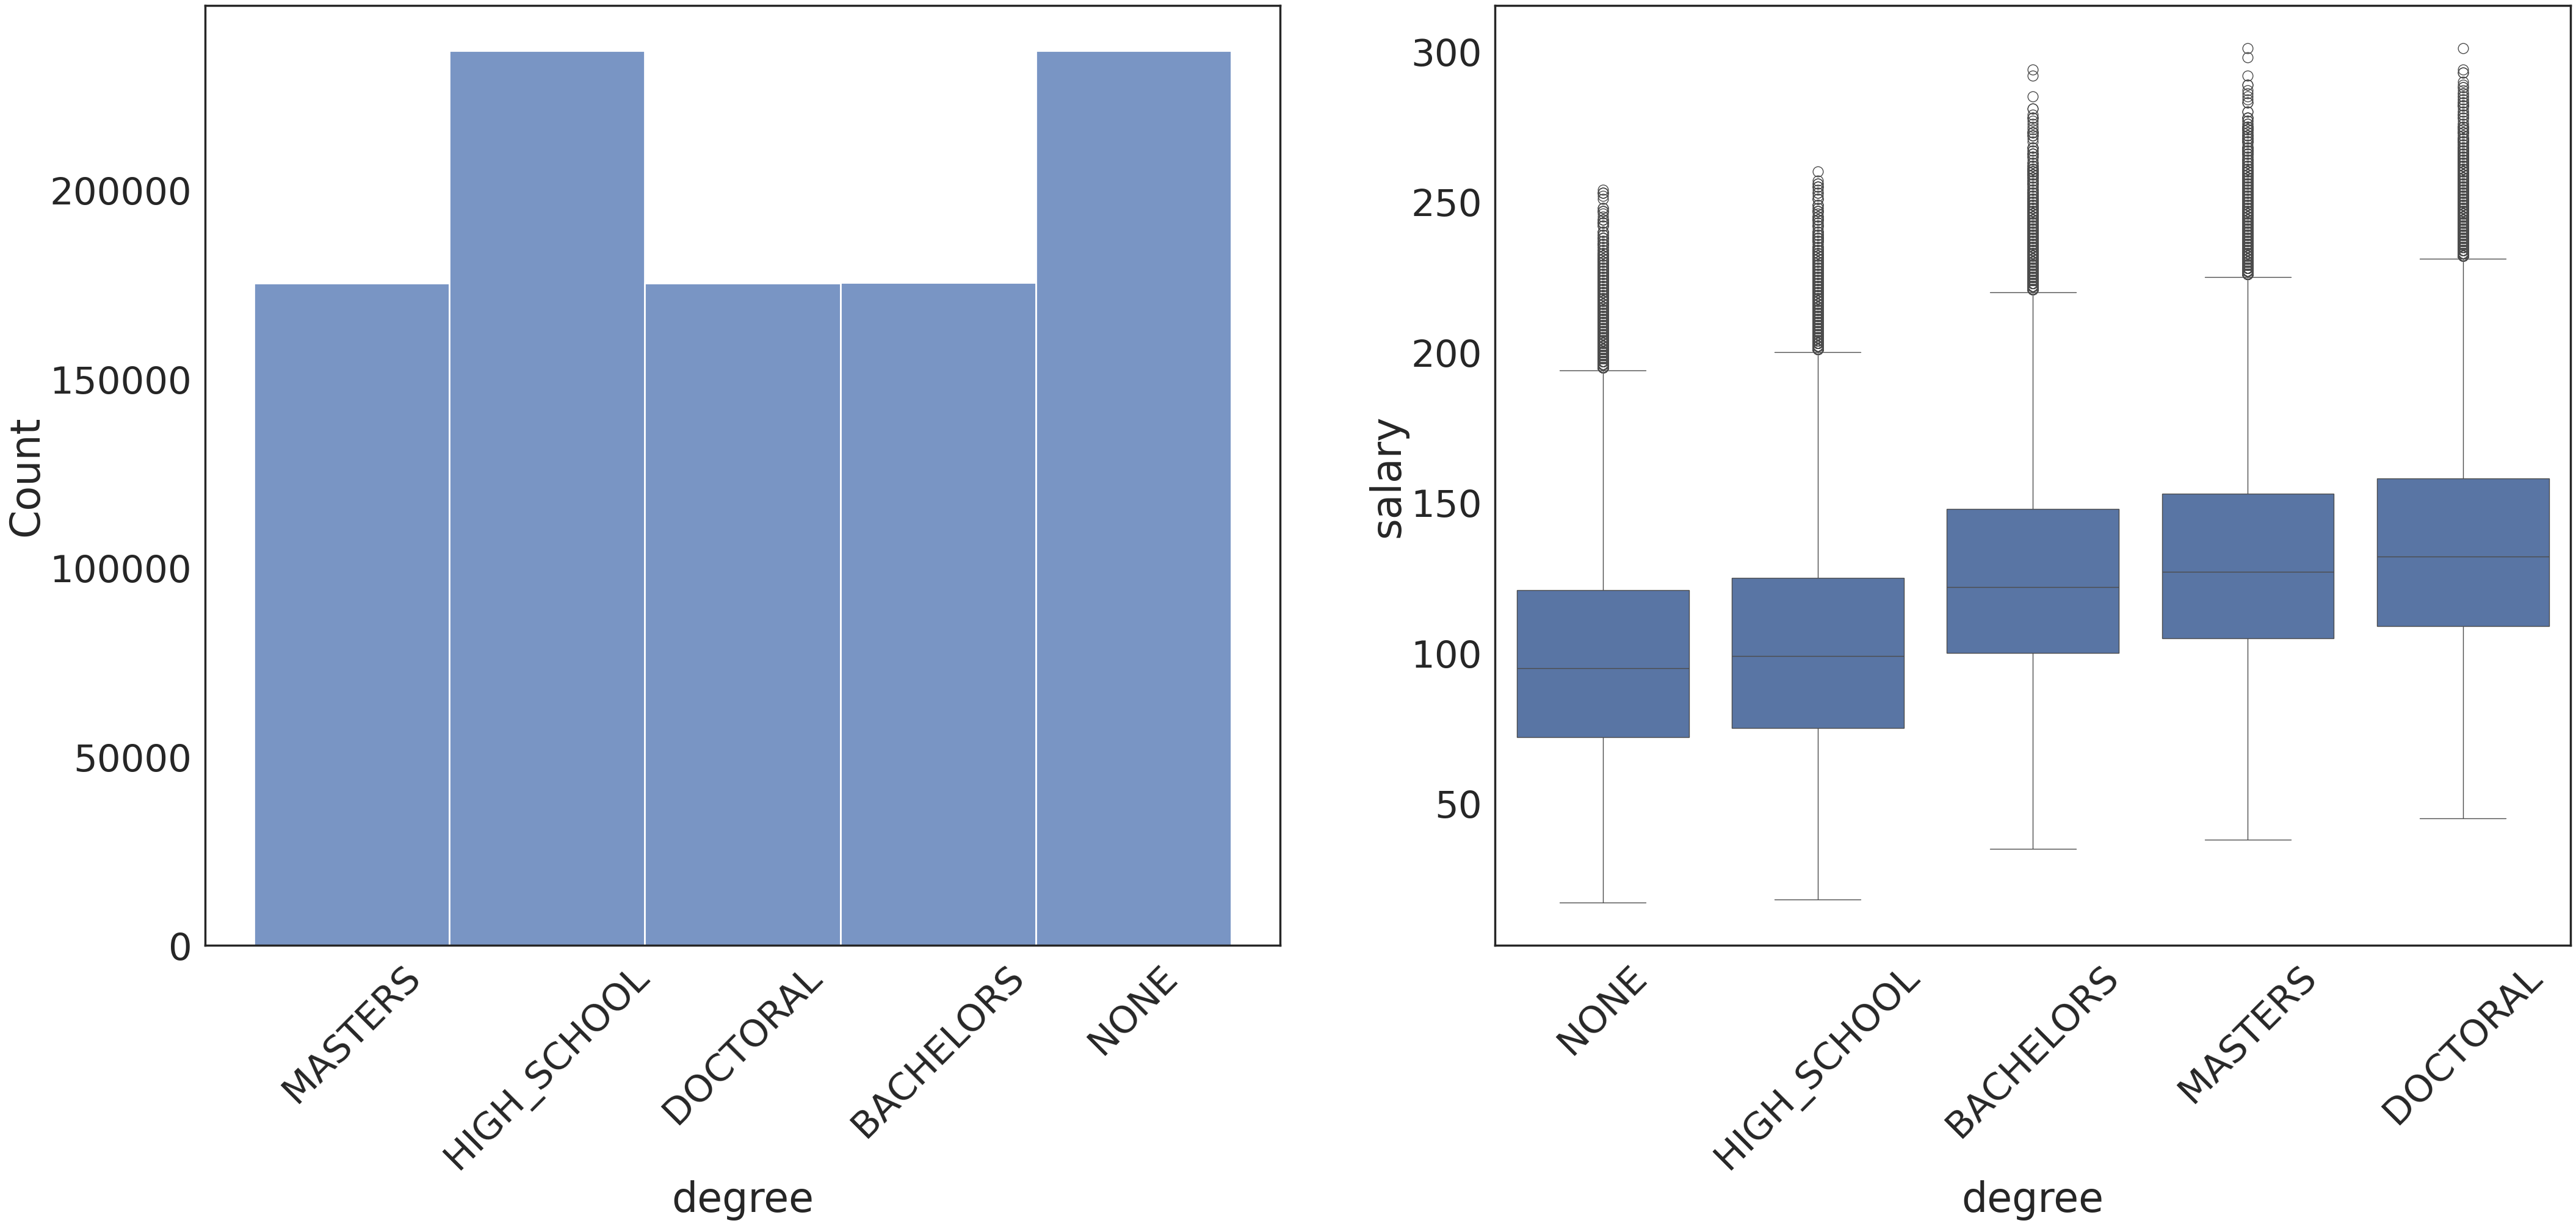

In [ ]:
#visualizing degree vs salary
meanorder = train_df.groupby(by=['degree'])['salary'].mean().sort_values().index
#sns.set_context("poster", font_scale=2)
plt.figure(figsize = (50, 20)) 
plt.subplot(1,2,1)
sns.histplot(x = 'degree', data = train_df) 
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.boxplot(x='degree', y='salary', data=train_df, order=meanorder)
plt.xticks(rotation=45)
plt.show()

Salary appears to be positively correlated with degree.  The more advanced the degree, the higher the salary.

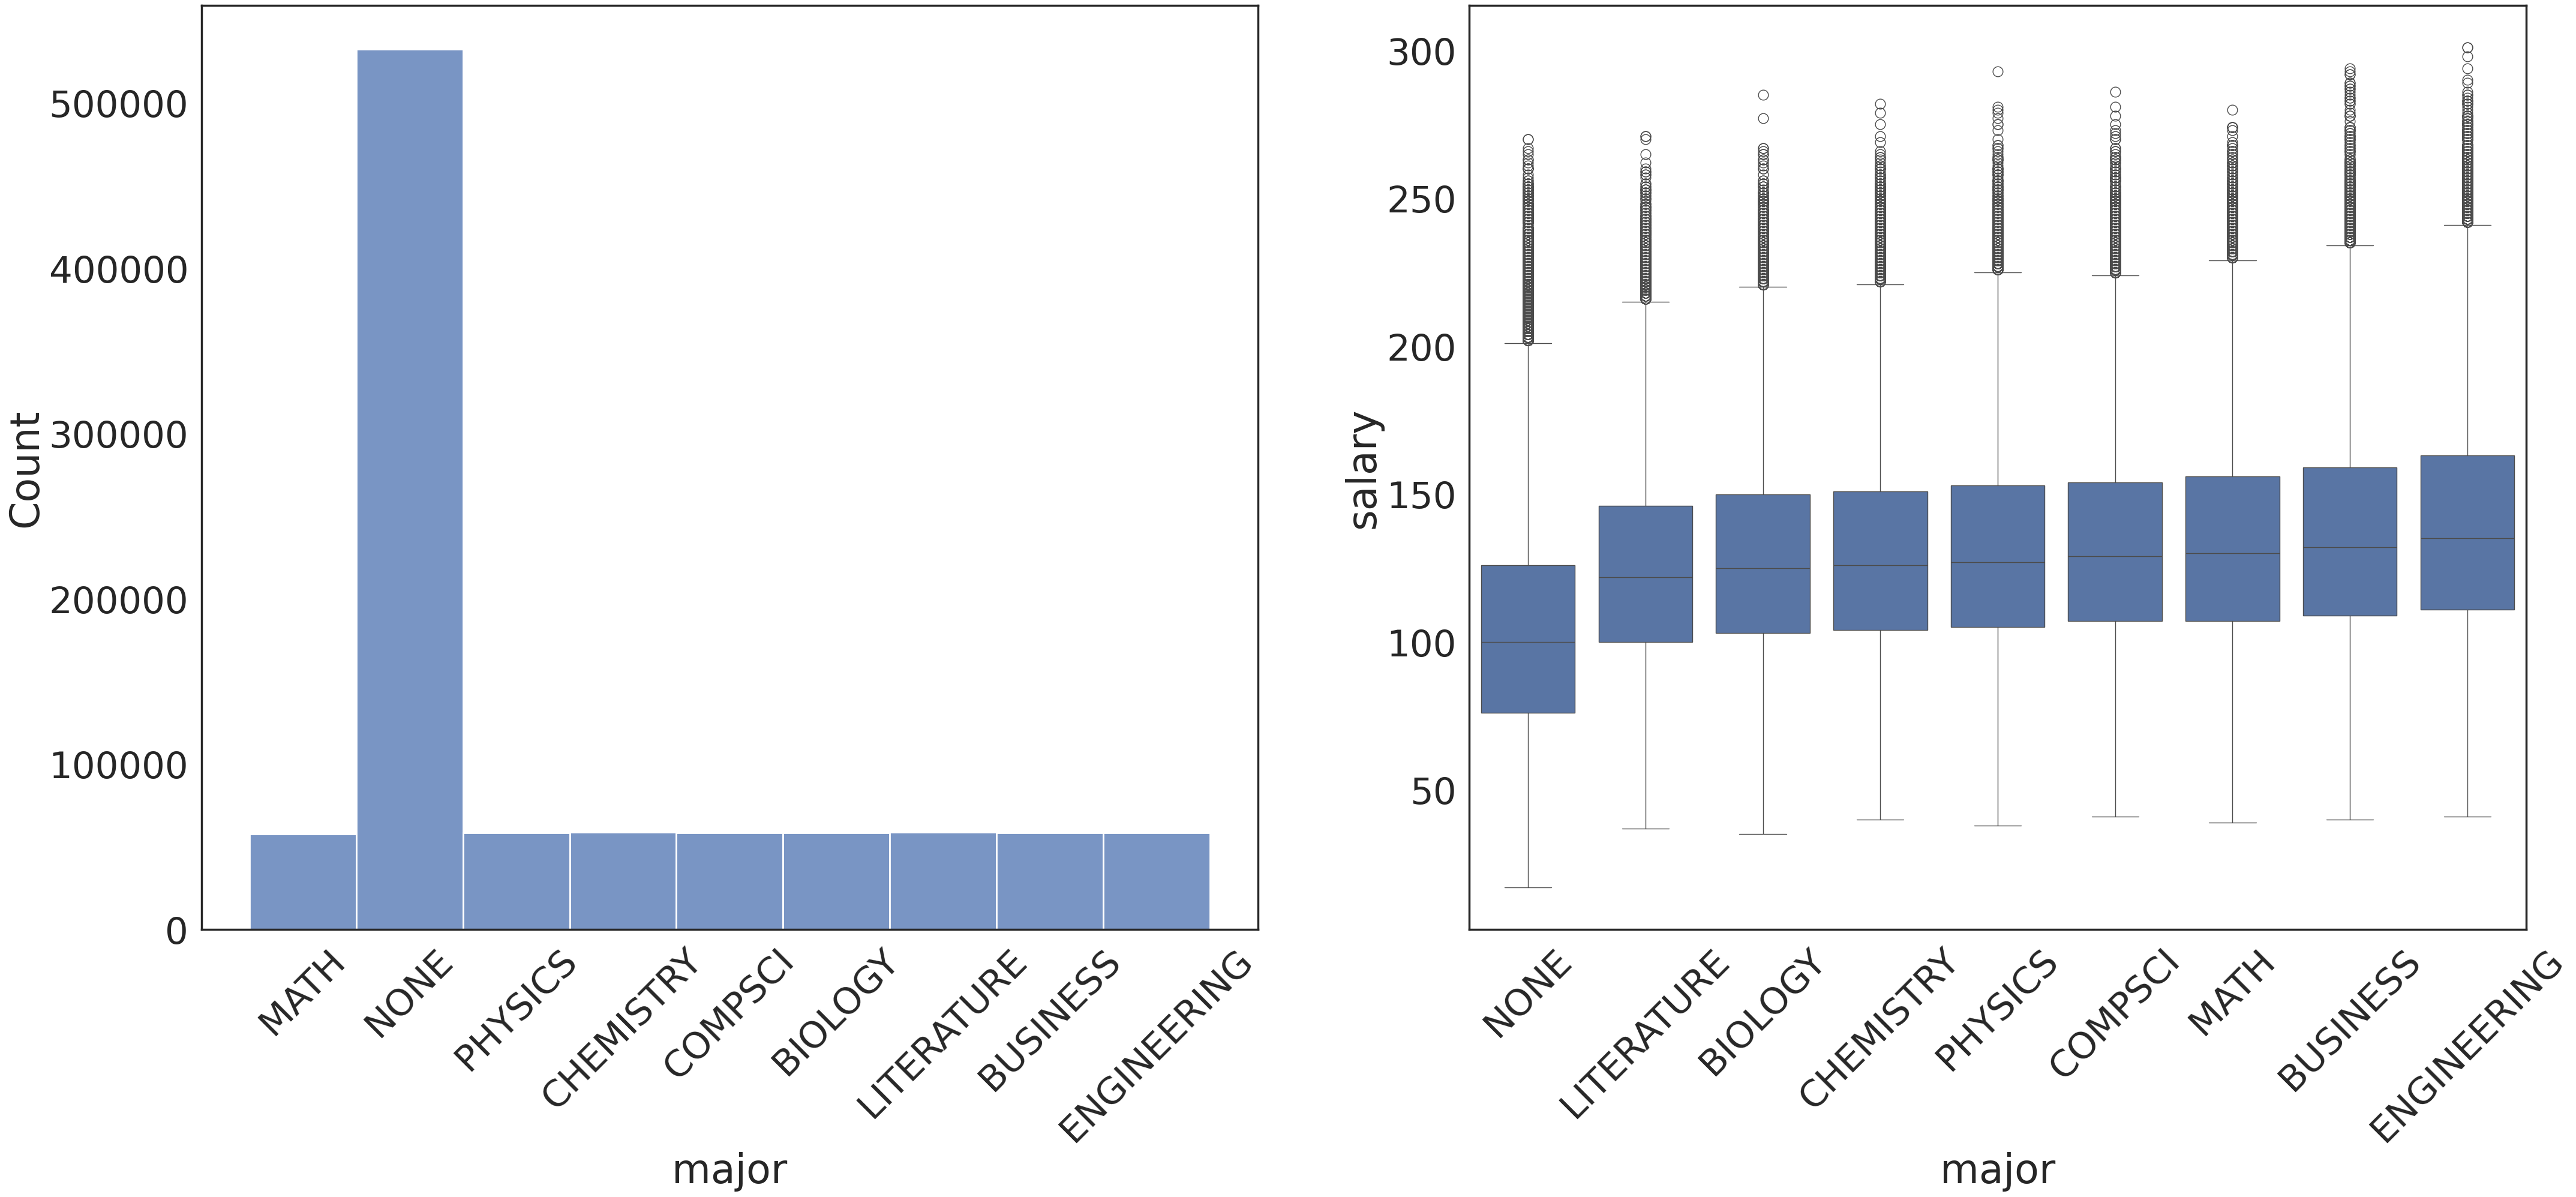

In [ ]:
#visualizing major vs salary
meanorder = train_df.groupby(by=['major'])['salary'].mean().sort_values().index
#sns.set_context("poster", font_scale=2)
plt.figure(figsize = (50, 20)) 
plt.subplot(1,2,1)
sns.histplot(x = 'major', data = train_df) 
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.boxplot(x='major', y='salary', data=train_df, order=meanorder)
plt.xticks(rotation=45)
plt.show()

Salary does not appear to have a strong correlation with major, with the exception of no major having a slightly lower salary and enginereering having a slightly higher salary

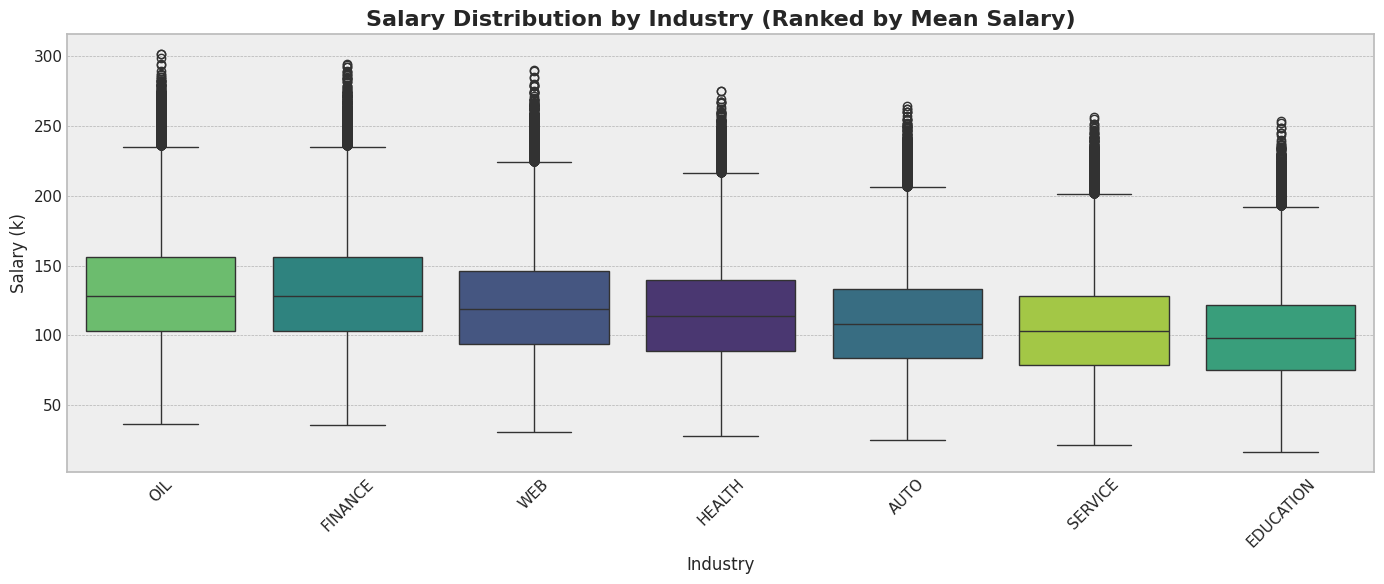

In [37]:
# Industry Analysis
sns.set_context("notebook") 
plt.style.use('bmh')
plt.figure(figsize=(14, 6))

# Sort by mean for the story
mean_order = train_df.groupby('industry')['salary'].mean().sort_values(ascending=False).index

sns.boxplot(data=train_df, x='industry', y='salary', order=mean_order, hue='industry', legend=False, palette='viridis')

plt.title('Salary Distribution by Industry (Ranked by Mean Salary)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Salary (k)', fontsize=12)
plt.xlabel('Industry', fontsize=12)

plt.tight_layout()
plt.show()


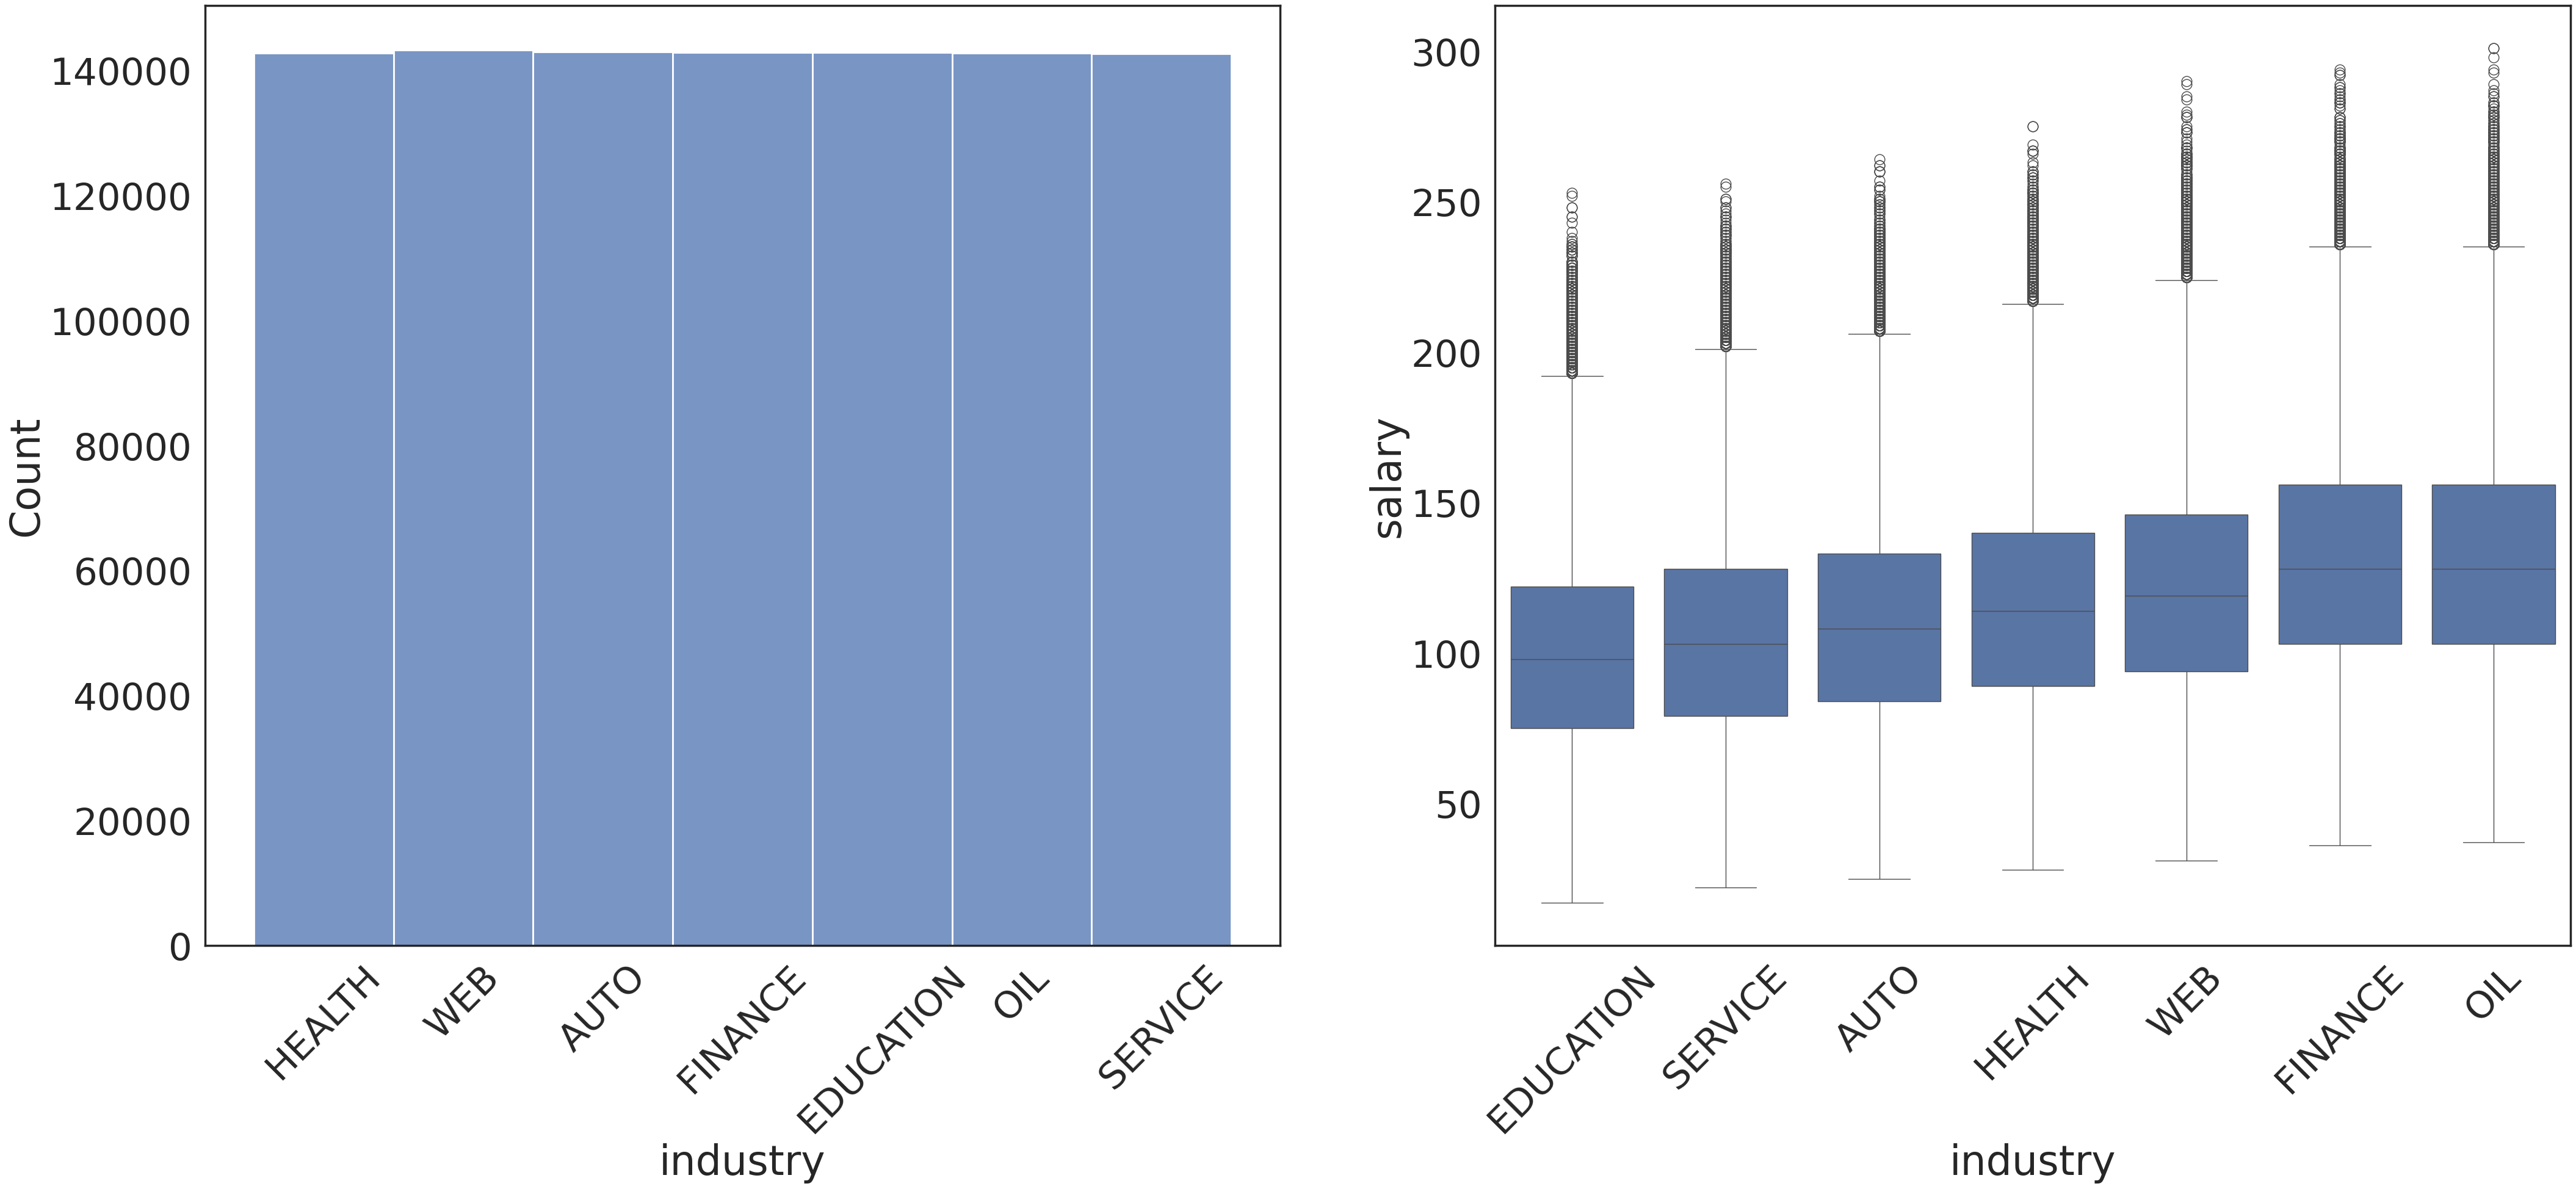

In [ ]:
#visualizing industry vs salary
meanorder = train_df.groupby(by=['industry'])['salary'].mean().sort_values().index
#sns.set_context("poster", font_scale=2)
plt.figure(figsize = (50, 20)) 
plt.subplot(1,2,1)
sns.histplot(x = 'industry', data = train_df) 
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.boxplot(x='industry', y='salary', data=train_df, order=meanorder)
plt.xticks(rotation=45)
plt.show()

Salary appears to be slightly correlated with industry.  Some industries earn slightly more than others

In [38]:
# Identify categorical columns
categorical_vars = ['jobType', 'degree', 'major', 'industry']

# One-Hot Encode (Modern Approach)
train_df2 = pd.get_dummies(train_df, columns=categorical_vars, drop_first=True)

# Quick check of  new features
print(f"Feature count jumped from {train_df.shape[1]} to {train_df2.shape[1]}")
train_df2.head()

Feature count jumped from 9 to 30


,jobId,companyId,yearsExperience,milesFromMetropolis,salary,jobType_CFO,jobType_CTO,jobType_JANITOR,jobType_JUNIOR,jobType_MANAGER,jobType_SENIOR,jobType_VICE_PRESIDENT,degree_DOCTORAL,degree_HIGH_SCHOOL,degree_MASTERS,degree_NONE,major_BUSINESS,major_CHEMISTRY,major_COMPSCI,major_ENGINEERING,major_LITERATURE,major_MATH,major_NONE,major_PHYSICS,industry_EDUCATION,industry_FINANCE,industry_HEALTH,industry_OIL,industry_SERVICE,industry_WEB
0,JOB1362684407687,COMP37,10,83,130,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False
1,JOB1362684407688,COMP19,3,73,101,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
2,JOB1362684407689,COMP52,10,38,137,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False
3,JOB1362684407690,COMP38,8,17,142,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,JOB1362684407691,COMP7,8,16,163,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False


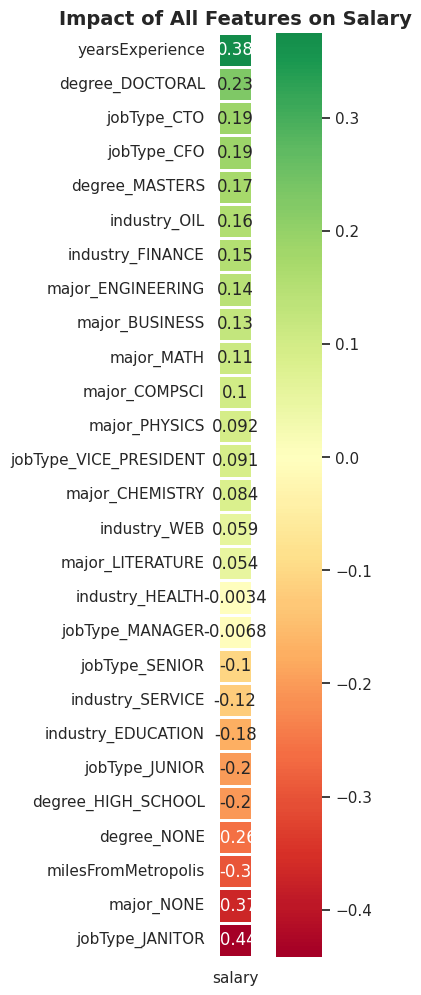

In [41]:
# 1. Re-run Encoding and force them to be integers (1/0)
categorical_vars = ['jobType', 'degree', 'major', 'industry']
train_df2 = pd.get_dummies(train_df, columns=categorical_vars, drop_first=True, dtype=int)

# 2. Select only the numeric data
numeric_df = train_df2.select_dtypes(include=[np.number])

# 3. Create the 'Impact' Heatmap
salary_correlations = numeric_df.corr()['salary'].sort_values(ascending=False).drop('salary')

plt.figure(figsize=(6, 12))
sns.heatmap(salary_correlations.to_frame(), 
            annot=True, 
            cmap='RdYlGn', 
            center=0, 
            square=True, 
            linewidths=1, 
            linecolor='white')

plt.title('Impact of All Features on Salary', fontsize=14, fontweight='bold')
plt.show()


In [42]:
print(numeric_df.columns)

Index(['yearsExperience', 'milesFromMetropolis', 'salary', 'jobType_CFO',
       'jobType_CTO', 'jobType_JANITOR', 'jobType_JUNIOR', 'jobType_MANAGER',
       'jobType_SENIOR', 'jobType_VICE_PRESIDENT', 'degree_DOCTORAL',
       'degree_HIGH_SCHOOL', 'degree_MASTERS', 'degree_NONE', 'major_BUSINESS',
       'major_CHEMISTRY', 'major_COMPSCI', 'major_ENGINEERING',
       'major_LITERATURE', 'major_MATH', 'major_NONE', 'major_PHYSICS',
       'industry_EDUCATION', 'industry_FINANCE', 'industry_HEALTH',
       'industry_OIL', 'industry_SERVICE', 'industry_WEB'],
      dtype='str')


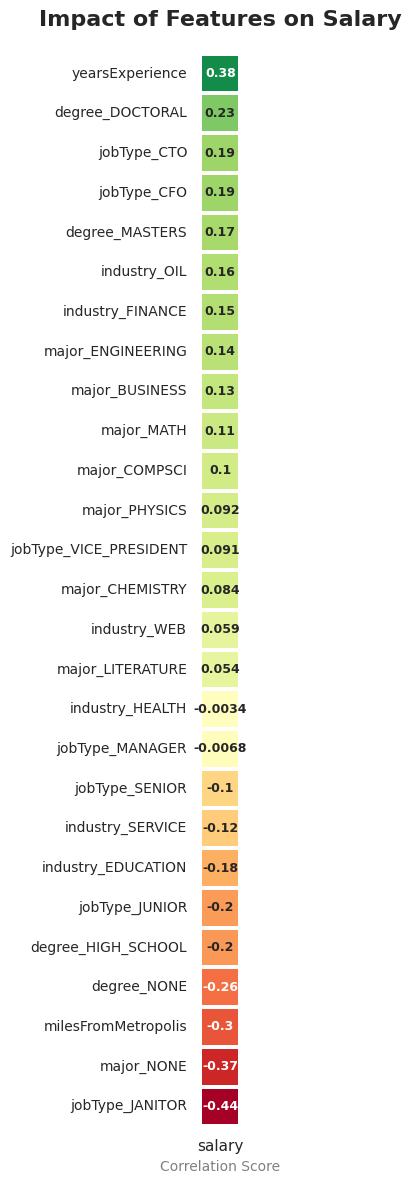

In [44]:
# 1. THE AESTHETIC RESET
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault) # Wipe out the 'Poster' ghost
sns.set_theme(style="white") 

# 2. Prepare the data
salary_correlations = numeric_df.corr()['salary'].sort_values(ascending=False).drop('salary')
corr_df = salary_correlations.to_frame()

# 3. THE PLOT
# We use a wider figsize (8) to give the labels room to breathe
plt.figure(figsize=(8, 12)) 

sns.heatmap(corr_df, 
            annot=True, 
            cmap='RdYlGn', 
            center=0, 
            square=True, 
            linewidths=1.5,
            linecolor='white',
            cbar=False,
            # This 'annot_kws' is the magic fix for huge numbers:
            annot_kws={"size": 9, "weight": "bold"}, 
            yticklabels=True)

# This fix shrinks the feature names on the left
plt.yticks(fontsize=10, rotation=0) 
plt.title('Impact of Features on Salary', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Correlation Score', fontsize=10, color='grey')

plt.tight_layout()
plt.show()


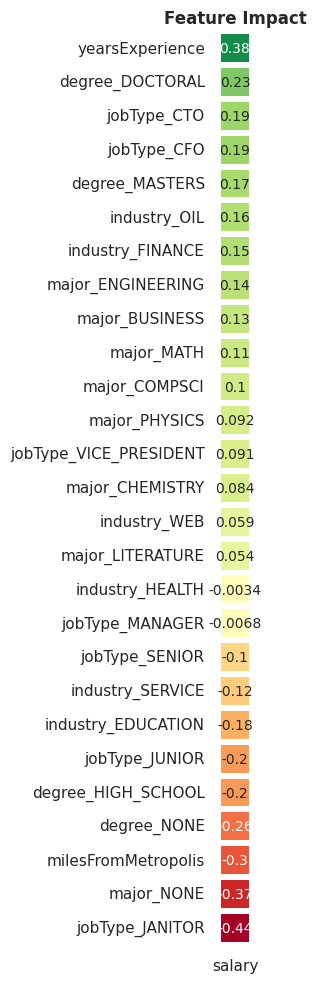

In [43]:
# 1. Force the data definition one last time
numeric_df = train_df2.select_dtypes(include=[np.number])
salary_correlations = numeric_df.corr()['salary'].sort_values(ascending=False).drop('salary')
corr_df = salary_correlations.to_frame()

# 2. THE NUCLEAR RESET: Wipe out all global 'poster' settings
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault) # Returns all fonts/sizes to factory settings
sns.set_theme(style="white", context="notebook") 

# 3. Create a small, forced-width plot
plt.figure(figsize=(4, 10)) # Very thin to force 'strip' look

sns.heatmap(corr_df, 
            annot=True, 
            cmap='RdYlGn', 
            center=0, 
            square=True,       # Forces squares
            linewidths=3,      # Thick borders to separate boxes
            linecolor='white', # High contrast border
            annot_kws={"size": 10}, # Forces the numbers inside to stay small
            cbar=False)        # Remove colorbar to save horizontal space

plt.title('Feature Impact', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


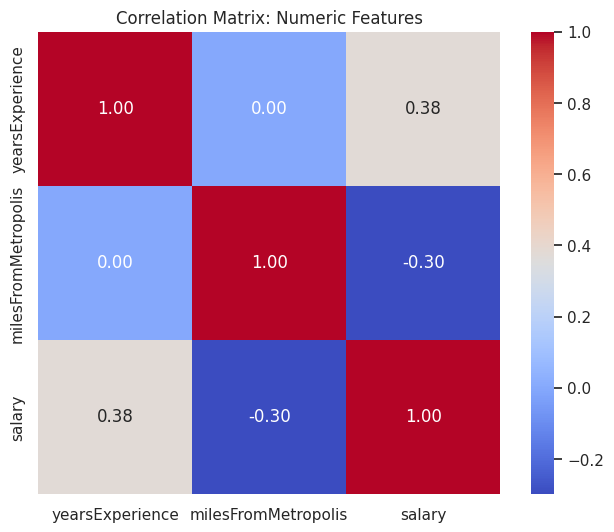

In [45]:
# Modern Pro Move: Keep the matrix simple and readable
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[['yearsExperience', 'milesFromMetropolis', 'salary']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix: Numeric Features')
plt.show()


In [1]:
# Pro move: show the top 10 strongest relationships in text form
print(numeric_df.corr()['salary'].sort_values(ascending=False).head(10))


NameError: name 'numeric_df' is not defined

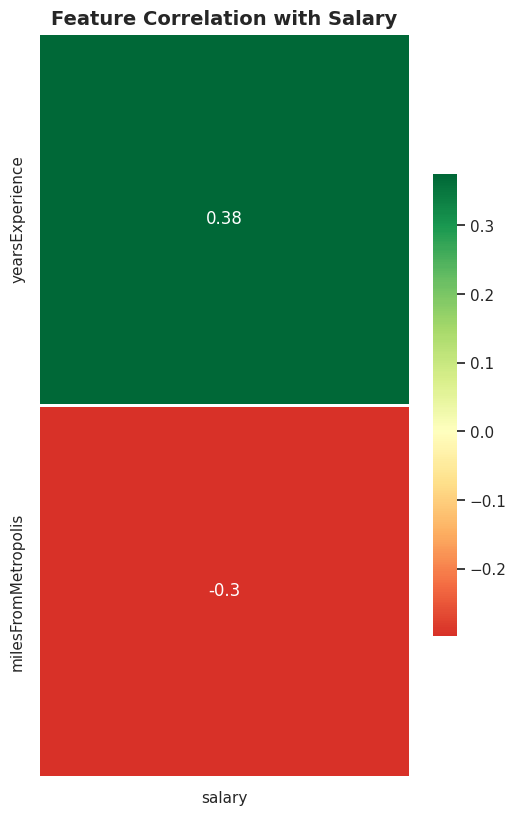

In [39]:
numeric_df = train_df2.select_dtypes(include=[np.number])
# 1. Reset everything to standard notebook sizes
sns.set_context("notebook", font_scale=1.0)
sns.set_style("white")

# 2. Prepare the data
salary_correlations = numeric_df.corr()['salary'].sort_values(ascending=False).drop('salary')
corr_df = salary_correlations.to_frame()

# 3. Create the plot with a fixed width
plt.figure(figsize=(6, 12)) 

# 'cbar=False' often helps prevent the squares from stretching 
sns.heatmap(corr_df, 
            annot=True, 
            cmap='RdYlGn', 
            center=0, 
            square=True,      # Forces actual squares
            linewidths=2,     # Thick white lines between squares
            linecolor='white',
            cbar_kws={"shrink": .5})

plt.title('Feature Correlation with Salary', fontsize=14, fontweight='bold')
plt.show()


In [22]:
# 1. Cleanly grab the correlations from the numeric dataframe
salary_correlations = numeric_df.corr()['salary'].sort_values(ascending=False).drop('salary')

# 2. Convert to frame for the plotter
corr_df = salary_correlations.to_frame()

# 3. Use a single, taller plot with a forced 'square' layout
plt.figure(figsize=(8, 14))

sns.heatmap(corr_df, 
            annot=True, 
            cmap='RdYlGn', 
            center=0, 
            square=True,      # This keeps the 'Big Two' as squares, not giant bars
            linewidths=0.5,   # Adds the grid lines you were missing
            cbar_kws={"shrink": .5})

plt.title('Relative Impact of All Features on Salary', fontsize=16, fontweight='bold')
plt.show()


NameError: name 'numeric_df' is not defined

ValueError: zero-size array to reduction operation fmin which has no identity

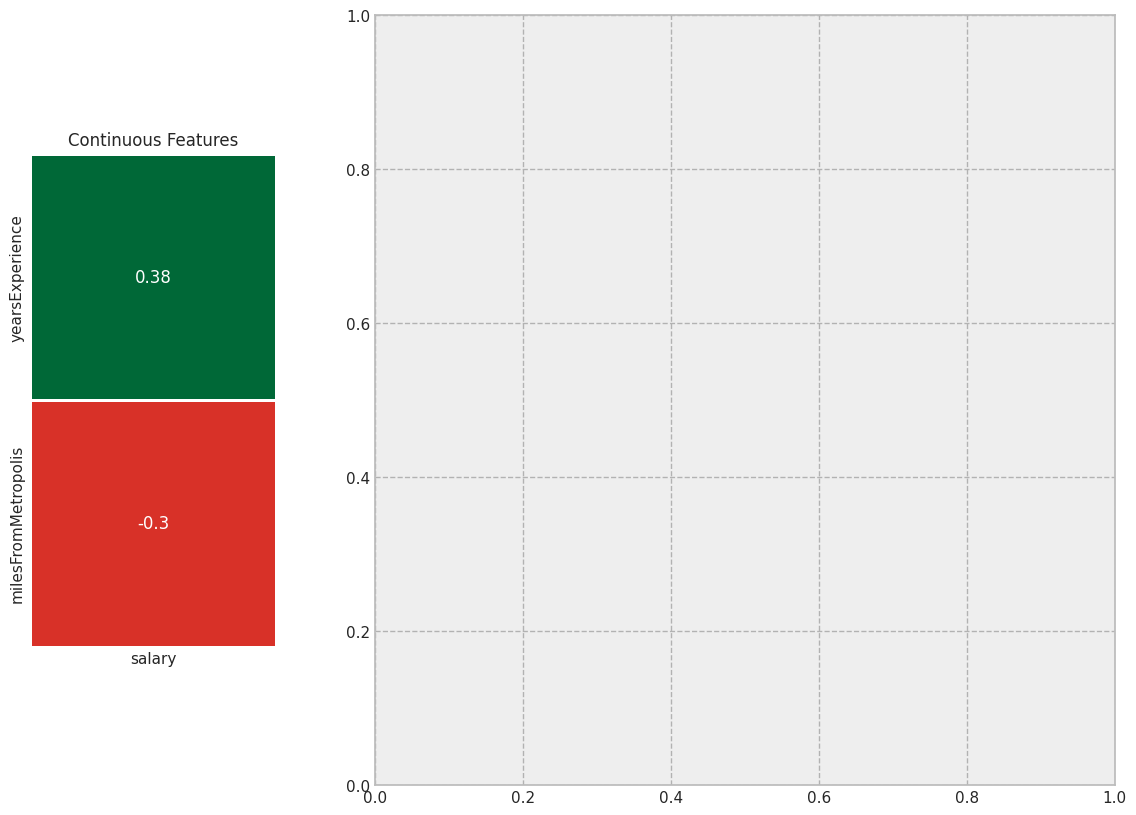

In [120]:
# 1. Split the correlations into two groups
salary_corr = numeric_df.corr()['salary'].drop('salary')

# Group A: The 'Big Two' continuous numbers
continuous_features = ['yearsExperience', 'milesFromMetropolis']
cont_corr = salary_corr[continuous_features].to_frame()

# Group B: Everything else (The encoded categories)
cat_corr = salary_corr.drop(continuous_features).sort_values(ascending=False).to_frame()

# 2. Plot them side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 10), gridspec_kw={'width_ratios': [1, 3]})

# Left side: The Continuous Features
sns.heatmap(cont_corr, annot=True, cmap='RdYlGn', center=0, ax=ax[0], cbar=False, square=True, linewidths=1)
ax[0].set_title('Continuous Features')

# Right side: The Categorical Features
sns.heatmap(cat_corr, annot=True, cmap='RdYlGn', center=0, ax=ax[1], square=True, linewidths=1)
ax[1].set_title('Encoded Categories')

plt.tight_layout()
plt.show()


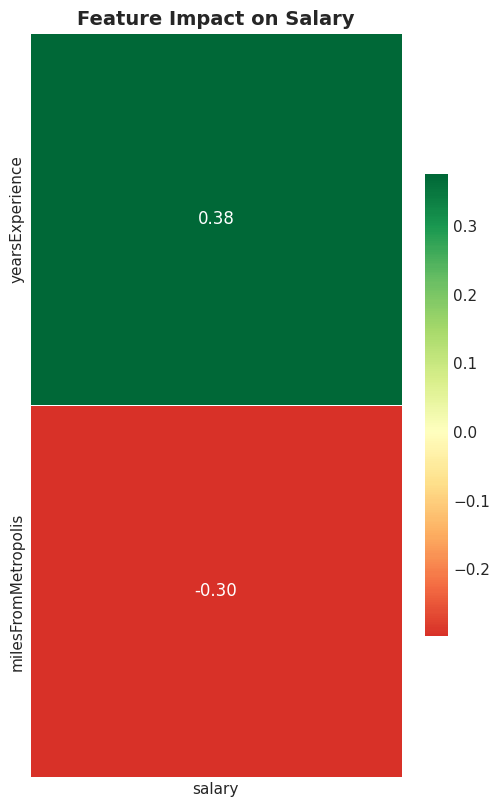

In [119]:
plt.figure(figsize=(6, 12)) # Make it thinner and taller

# 1. Grab the correlations
salary_correlations = numeric_df.corr()['salary'].sort_values(ascending=False).drop('salary')

# 2. Plot with 'square=True' and 'linewidths' to force a grid look
sns.heatmap(salary_correlations.to_frame(), 
            annot=True, 
            cmap='RdYlGn', 
            fmt='.2f',
            center=0,
            square=True,      # This forces the cells to be squares, not giant rectangles
            linewidths=0.5,   # This adds a white border between squares
            cbar_kws={"shrink": .5}) # Makes the color bar smaller

plt.title('Feature Impact on Salary', fontsize=14, fontweight='bold')
plt.show()


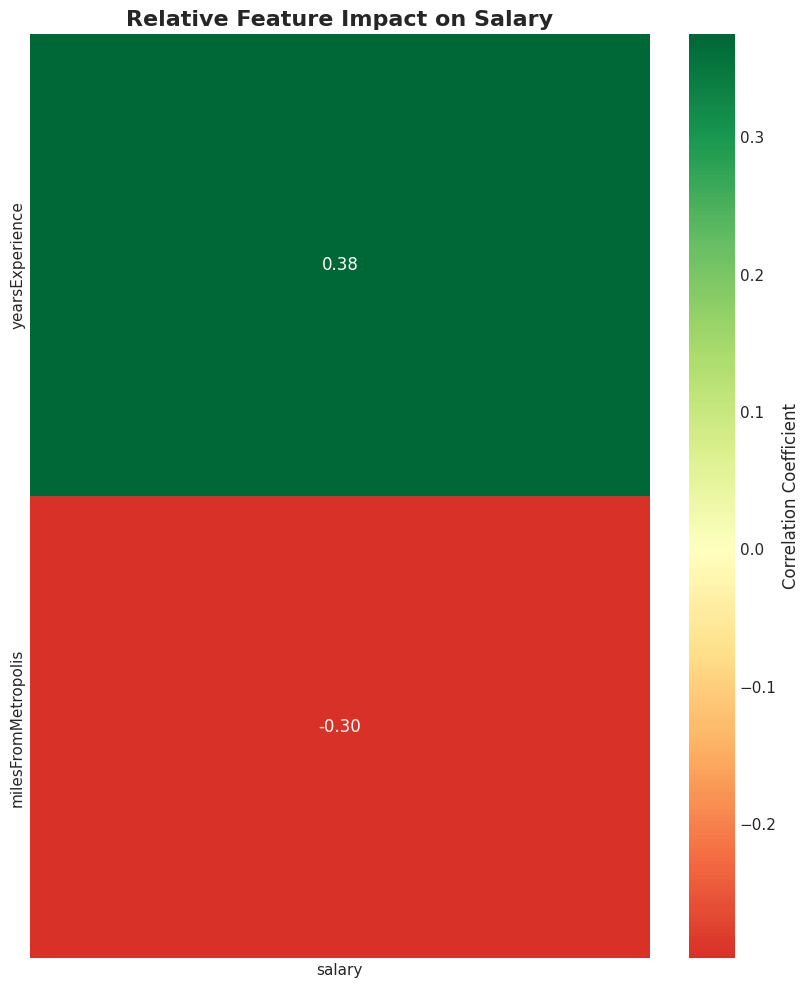

In [118]:
plt.figure(figsize=(10, 12))

# 1. Grab the correlations
salary_correlations = numeric_df.corr()['salary'].sort_values(ascending=False).drop('salary')

# 2. Convert to a DataFrame so Seaborn can handle it easily
corr_df = salary_correlations.to_frame()

# 3. Plot without 'vmin' and 'vmax' first to let Seaborn auto-balance
sns.heatmap(corr_df, 
            annot=True, 
            cmap='RdYlGn', 
            fmt='.2f',
            center=0, # This keeps 0 as the neutral 'yellow' color
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Relative Feature Impact on Salary', fontsize=16, fontweight='bold')
plt.show()


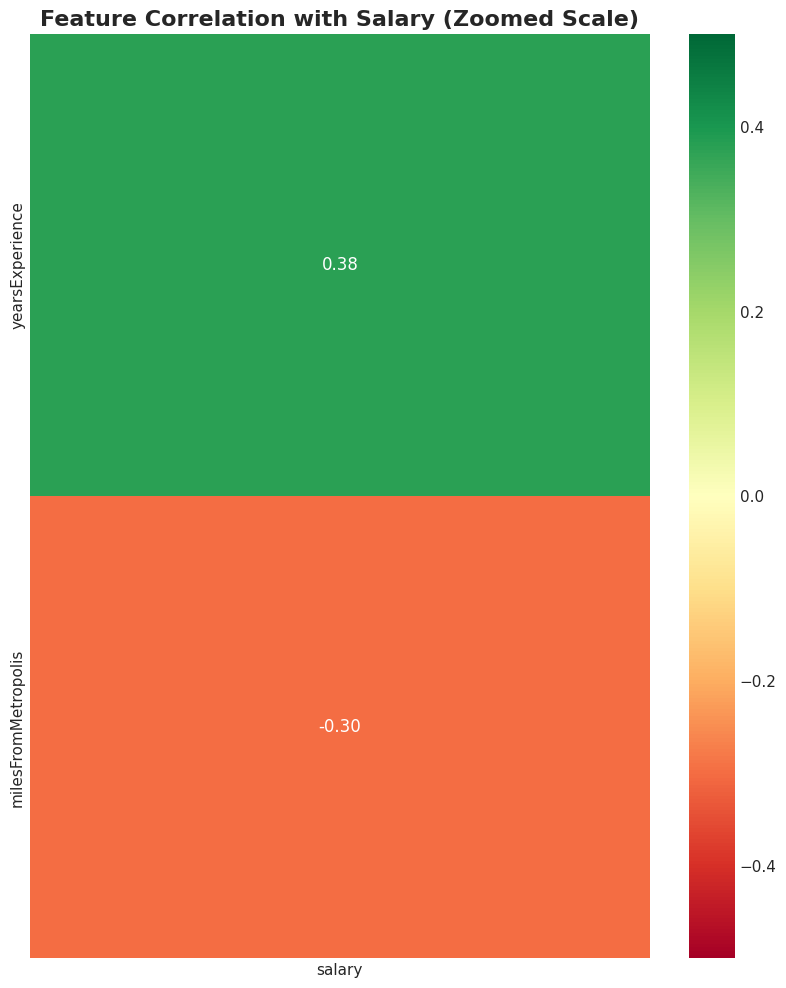

In [117]:
# Modern Fix: Use a tighter color scale to see the subtle differences
plt.figure(figsize=(10, 12))
salary_correlations = numeric_df.corr()['salary'].sort_values(ascending=False).drop('salary')

# We set vmin and vmax to -0.5 and 0.5 to 'zoom in' on the colors
# Even if CEO is 0.9, this makes the smaller correlations (like 0.2) more visible
sns.heatmap(salary_correlations.to_frame(), 
            annot=True, 
            cmap='RdYlGn', 
            fmt='.2f', 
            vmin=-0.5, vmax=0.5, 
            center=0)

plt.title('Feature Correlation with Salary (Zoomed Scale)', fontsize=16, fontweight='bold')
plt.show()


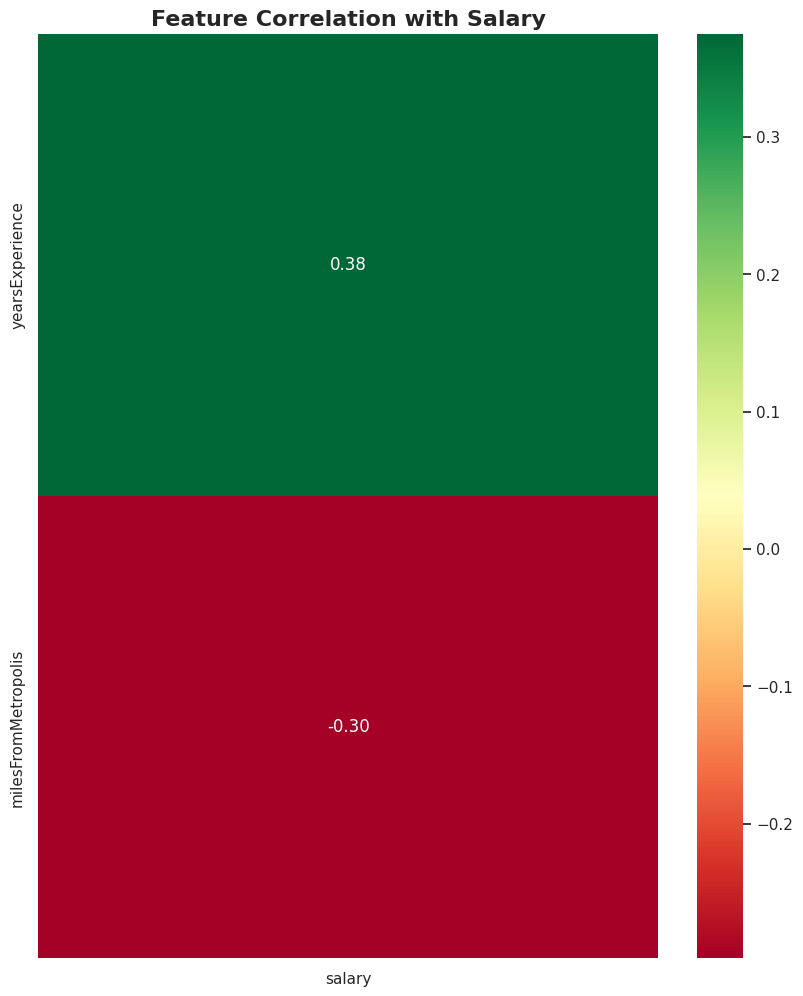

In [27]:
# Modern Fix: Select only numeric columns before calculating correlation
# This ignores jobId, companyId, and any other text columns
numeric_df = train_df2.select_dtypes(include=[np.number])

# Calculate the correlation on just the numbers
plt.figure(figsize=(10, 12))
salary_correlations = numeric_df.corr()['salary'].sort_values(ascending=False).drop('salary')

sns.heatmap(salary_correlations.to_frame(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation with Salary', fontsize=16, fontweight='bold')
plt.show()

In [115]:
# Filter the correlation to only show how features relate to SALARY
plt.figure(figsize=(10, 12))
salary_correlations = train_df2.corr()['salary'].sort_values(ascending=False).drop('salary')

sns.heatmap(salary_correlations.to_frame(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation with Salary', fontsize=16, fontweight='bold')
plt.show()


ValueError: could not convert string to float: 'JOB1362684407687'

<Figure size 1000x1200 with 0 Axes>

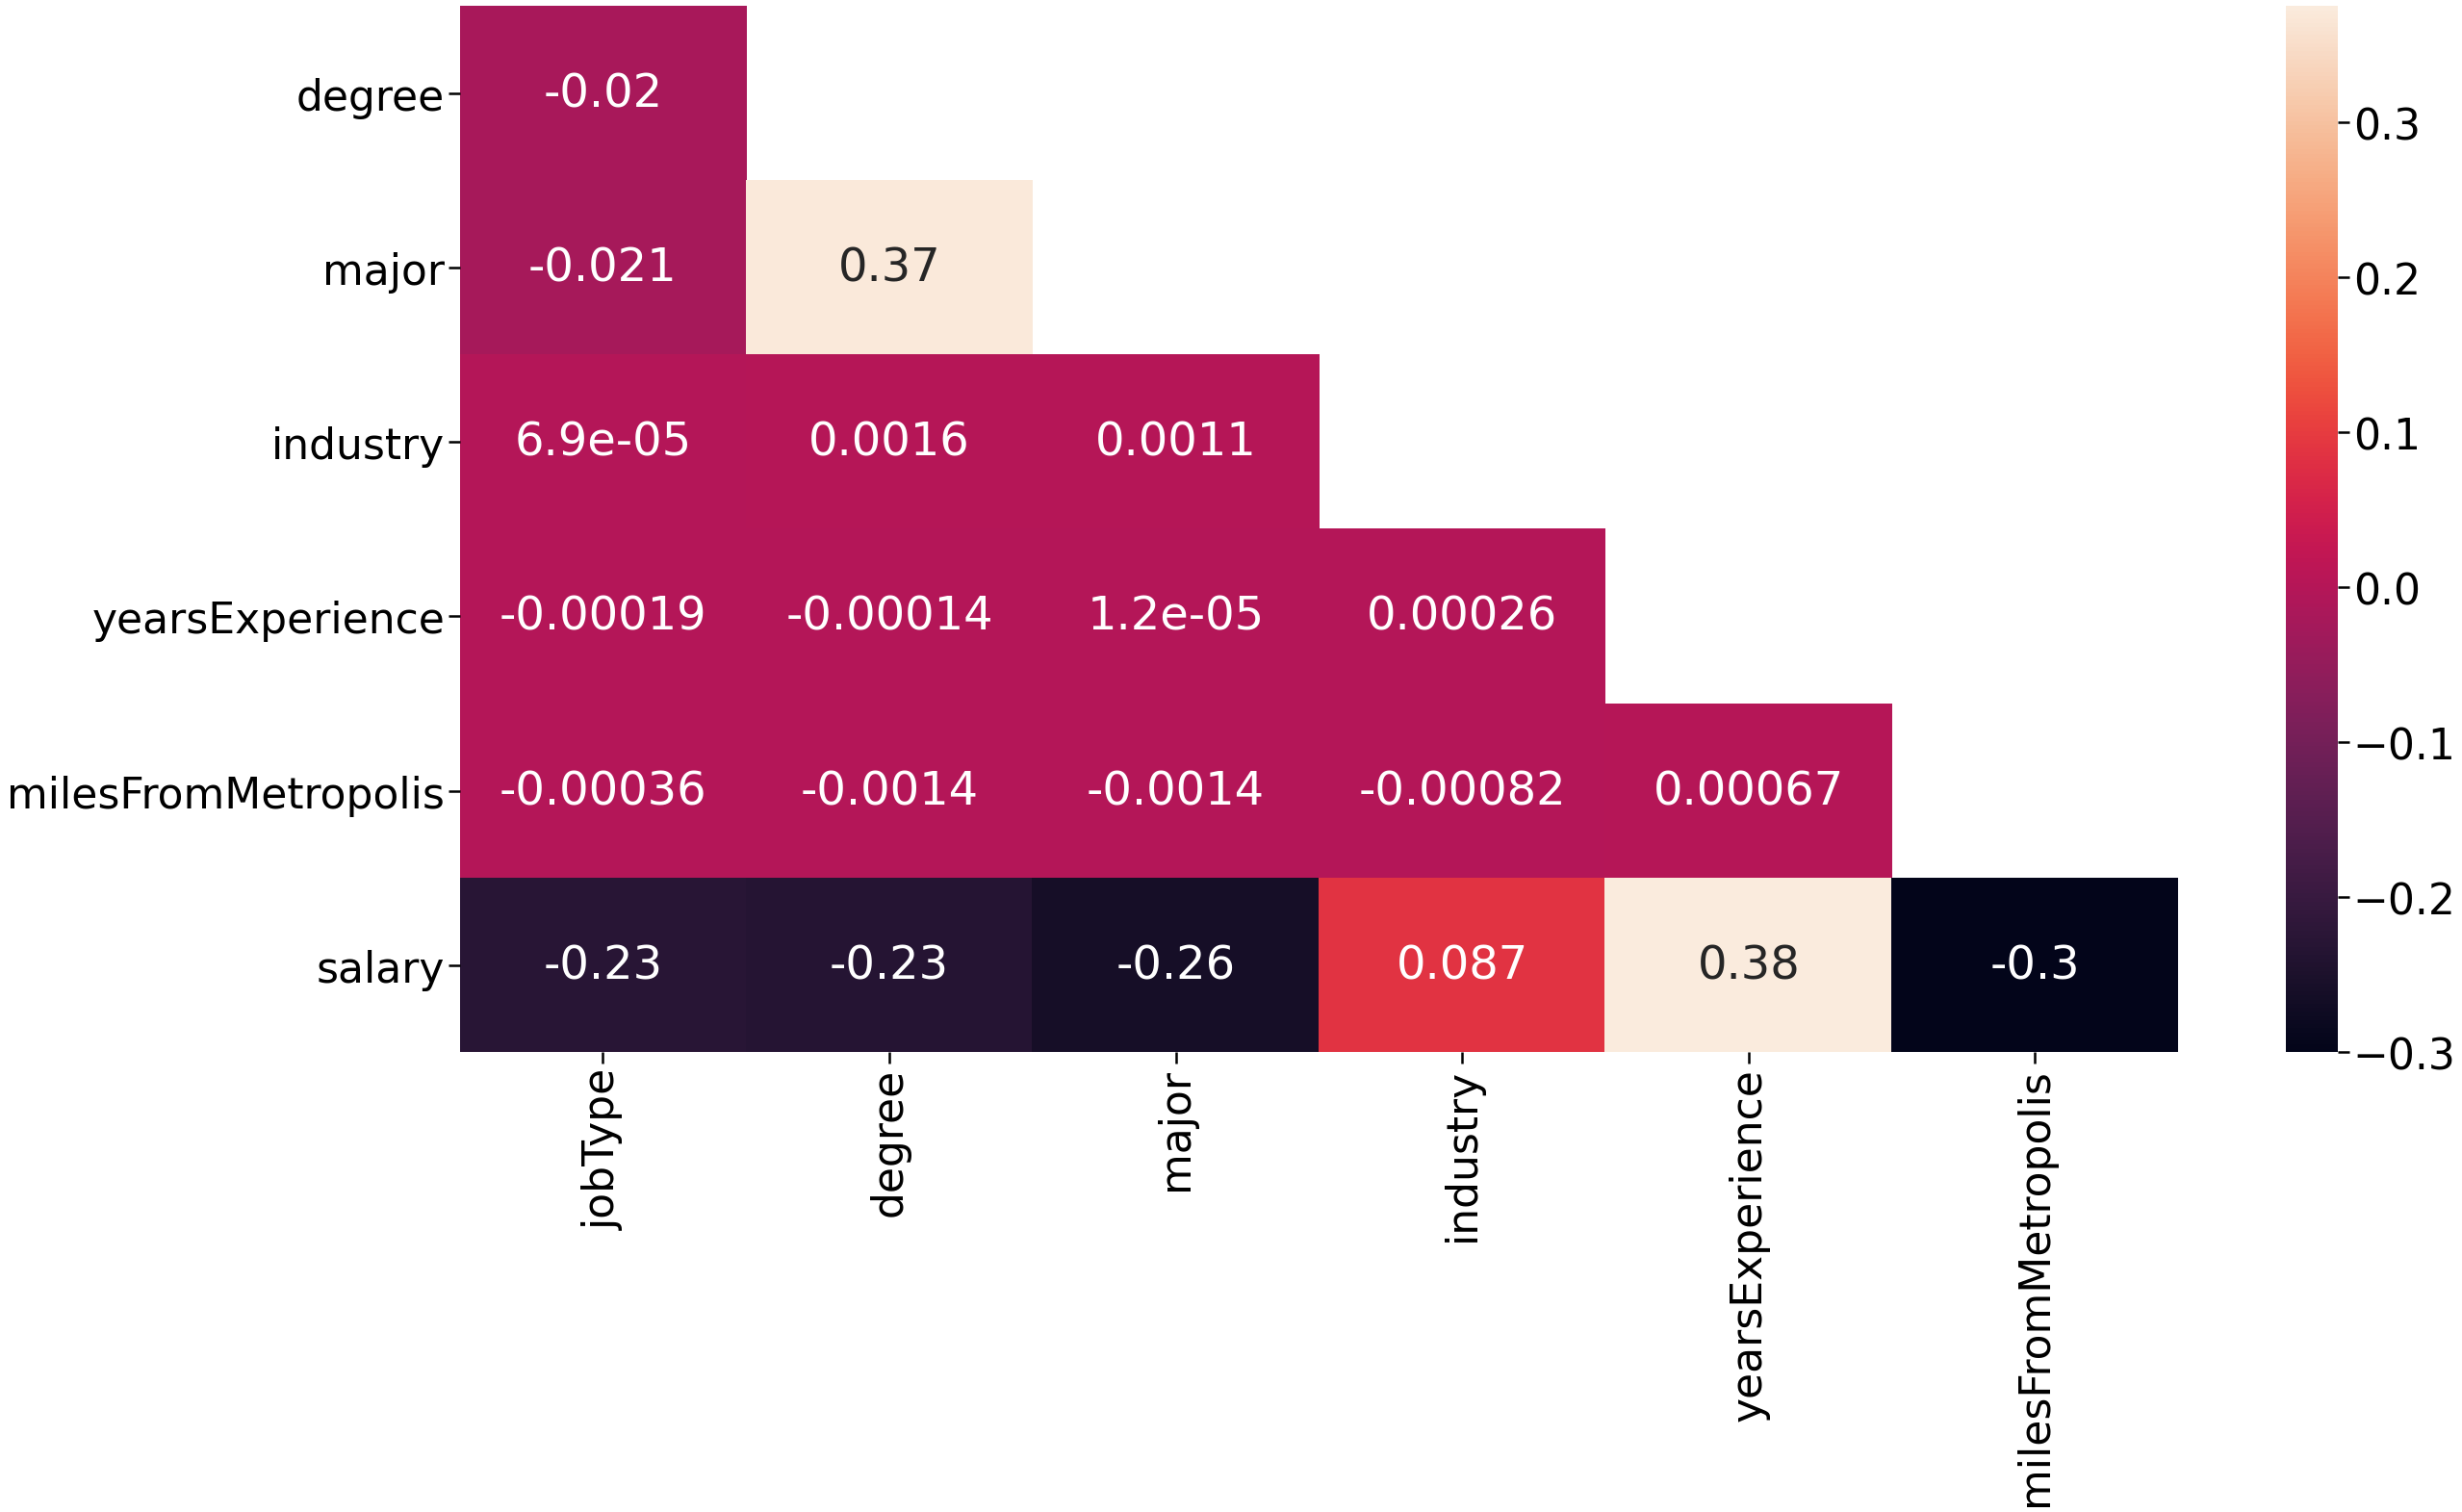

In [ ]:
#visualizing between features
plt.figure(figsize = (40, 20)) 
#sns.set_context("poster", font_scale=2)
features = ['jobType', 'degree', 'major', 'industry', 'yearsExperience', 'milesFromMetropolis', 'salary']
sns.diverging_palette(130, 50, as_cmap=True)
df_corr = train_df2[features].corr()
mask = np.triu(np.ones_like(df_corr, dtype=np.bool))
mask = mask[1:, :-1]
corr = df_corr.iloc[1:,:-1].copy()
sns.heatmap(corr, annot=True, mask=mask, vmin=-0.3)
plt.show()

The feature variables are not very correlated with each other

### ---- 5 Establish a baseline ----

In [41]:
#creating simple model to measure efficacy
train_df_bl = train_df.groupby('industry', as_index = False).mean()
train_df_bl.rename(columns = {'salary':'avg_salary'}, inplace = True)
train_df_bl = df_baseline[['industry', 'avg_salary']]
train_df_bl

,industry,avg_salary
0,AUTO,109.433690
1,EDUCATION,99.448386
2,FINANCE,130.746743
3,HEALTH,115.735540
4,OIL,130.952946
5,SERVICE,104.446820
6,WEB,121.644512


In [42]:
train_df2 = pd.merge(train_df, train_df_bl, on='industry')
train_df2

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis,salary,avg_salary
0,JOB1362684407687,COMP37,CFO,MASTERS,MATH,HEALTH,10,83,130,115.73554
1,JOB1362684407689,COMP52,VICE_PRESIDENT,DOCTORAL,PHYSICS,HEALTH,10,38,137,115.73554
2,JOB1362684407693,COMP15,CFO,NONE,NONE,HEALTH,23,24,178,115.73554
3,JOB1362684407697,COMP56,JANITOR,HIGH_SCHOOL,NONE,HEALTH,24,30,102,115.73554
4,JOB1362684407709,COMP30,JUNIOR,BACHELORS,LITERATURE,HEALTH,18,69,105,115.73554
...,...,...,...,...,...,...,...,...,...,...
999995,JOB1362685407660,COMP58,MANAGER,DOCTORAL,LITERATURE,SERVICE,3,51,117,104.44682
999996,JOB1362685407663,COMP61,VICE_PRESIDENT,MASTERS,LITERATURE,SERVICE,18,72,112,104.44682
999997,JOB1362685407665,COMP53,VICE_PRESIDENT,NONE,NONE,SERVICE,18,94,93,104.44682
999998,JOB1362685407671,COMP1,CTO,NONE,NONE,SERVICE,6,20,110,104.44682


In [40]:
#measuring MSE of baseline
mean_squared_error(train_df2.salary, train_df2.avg_salary)

1367.1891080861153

### ---- 6 Hypothesize solution ----

3 models that may improve results over the mean are... 
- linear regression because the relationships between the features and targets appear to be linear and we're attempting to find a continuous value
- random forest regression because the relationships may not be very linear
- gradient boosting regression because this should give us improved accuracy over random forest

## Part 3 - DEVELOP

Cycling through creating features, tuning models, and training / validing models (steps 7-9) until reaching efficacy goal. Metric will be MSE and goal is: <370 

### ---- 7 Engineer features  ----

In [7]:
x = train_df.iloc[:,:-1]

In [8]:
#dropping jobid and company id because no correlation
x = x.drop(columns=['jobId','companyId'])

In [9]:
#getting dummy values for categorical variables 
x = pd.get_dummies(data=x, columns=['jobType' , 'degree' , 'major', 'industry'])

In [10]:
#scaling min max values 
scaler = MinMaxScaler()
x[['yearsExperience', 'milesFromMetropolis']] = scaler.fit_transform(x[['yearsExperience', 'milesFromMetropolis']])

In [39]:
x

,yearsExperience,milesFromMetropolis,jobType_CEO,jobType_CFO,jobType_CTO,jobType_JANITOR,jobType_JUNIOR,jobType_MANAGER,jobType_SENIOR,jobType_VICE_PRESIDENT,degree_BACHELORS,degree_DOCTORAL,degree_HIGH_SCHOOL,degree_MASTERS,degree_NONE,major_BIOLOGY,major_BUSINESS,major_CHEMISTRY,major_COMPSCI,major_ENGINEERING,major_LITERATURE,major_MATH,major_NONE,major_PHYSICS,industry_AUTO,industry_EDUCATION,industry_FINANCE,industry_HEALTH,industry_OIL,industry_SERVICE,industry_WEB
0,0.416667,0.838384,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
1,0.125000,0.737374,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
2,0.416667,0.383838,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
3,0.333333,0.171717,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0.333333,0.161616,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.791667,0.949495,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
999996,0.500000,0.353535,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
999997,0.666667,0.818182,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
999998,0.250000,0.050505,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0


In [11]:
y = train_df.iloc[:,-1:].values
y

array([[130],
       [101],
       [137],
       ...,
       [ 64],
       [149],
       [ 88]])

In [12]:
#defining train and test 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33)

### ---- 8 Creating models ----

In [29]:
#creating linear regression object
print('starting...')
lr = linear_model.LinearRegression()

#training the model using the training sets
lr.fit(x_train, y_train)

#making predictions using the testing set
y_pred = lr.predict(x_test)

#getting Mean Squared Error
print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))

starting...
Mean squared error: 384.16


In [36]:
#creating random forest regressor object
print('starting...')
RFreg = RandomForestRegressor(n_estimators = 100, max_depth = 15, max_features = 15, random_state = 0)
  
#fitting the regressor with x and y data
RFreg.fit(x_train, y_train.ravel())  

#making predictions using the testing set
y_pred = RFreg.predict(x_test)  

#getting Mean Squared Error
print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))

starting...
Mean squared error: 375.41


In [1]:
# getting best hyperparameters for gradient boosting regressor
param = {'max_depth': [5, 10, 20, None],
         'learning_rate':[.01, 1.0, 10], 
         'max_features':[10, 20, 30],
         'min_samples_split': [5, 10, 20]}

In [62]:
rnd_search = RandomizedSearchCV(GradientBoostingRegressor(), param, 
n_iter =10, cv=2)
rnd_search.fit(x,y.ravel())
print(rnd_search.best_params_)
print(rnd_search.best_score_)

/home/kevin/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_search.py:925: RuntimeWarning: overflow encountered in square
  array_stds = np.sqrt(np.average((array -


{'min_samples_split': 10, 'max_features': 30, 'max_depth': 5, 'learning_rate': 1.0}
0.7575668218658309


In [64]:
rnd_search.best_params_

{'min_samples_split': 10,
 'max_features': 30,
 'max_depth': 5,
 'learning_rate': 1.0}

In [65]:
rnd_search.best_score_

0.7575668218658309

In [13]:
#creating gradient boosting regressor object
GBreg = GradientBoostingRegressor(learning_rate = 1, max_depth = 5, max_features = 30, min_samples_split = 10, n_estimators = 150, random_state = 0)

#fitting the regressor with x and y data
GBreg.fit(x_train, y_train.ravel())

#making predictions using the testing set
y_pred = GBreg.predict(x_test)

#getting Mean Squared Error
print('Mean squared error: %.2f'
      % mean_squared_error(y_test, y_pred))

Mean squared error: 362.51


### ---- 9 Test models ----

In [31]:
cvlr = cross_val_score(lr, x, y, cv=5, scoring='neg_mean_squared_error')
mselr = np.average(cvlr)
print(mselr)

-384.416247434276


In [38]:
cvrf = cross_val_score(RFreg, x, y.ravel(), cv=5, scoring='neg_mean_squared_error')
mserf = np.average(cvrf)
print(mserf)

-374.98021228590505


In [34]:
cvgb = cross_val_score(GBreg, x, y.ravel(), cv=2, scoring='neg_mean_squared_error')
msegb = np.average(cvgb) 
print(msegb)

-364.7344790085994


### ---- 10 Select best model  ----

In [40]:
MSEdf = pd.DataFrame(columns = ['Model', 'MSE'])
MSEdf

,Model,MSE


In [41]:
MSEdf.loc[len(MSEdf.index)] = ['LR', mselr] 
MSEdf

,Model,MSE
0,LR,-384.416247


In [42]:
MSEdf.loc[len(MSEdf.index)] = ['RFreg', mserf]
MSEdf

,Model,MSE
0,LR,-384.416247
1,RFreg,-374.980212


In [43]:
MSEdf.loc[len(MSEdf.index)] = ['GBreg', msegb]
MSEdf

,Model,MSE
0,LR,-384.416247
1,RFreg,-374.980212
2,GBreg,-364.734479


In [44]:
MSEdf.min()

Model         GBreg
MSE     -384.416247
dtype: object

## Part 4 - DEPLOY

### ---- 12 Deploy solution ----

In [14]:
#preparing test features
test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   jobId                1000000 non-null  object
 1   companyId            1000000 non-null  object
 2   jobType              1000000 non-null  object
 3   degree               1000000 non-null  object
 4   major                1000000 non-null  object
 5   industry             1000000 non-null  object
 6   yearsExperience      1000000 non-null  int64 
 7   milesFromMetropolis  1000000 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 61.0+ MB


In [15]:
test_features.head()

,jobId,companyId,jobType,degree,major,industry,yearsExperience,milesFromMetropolis
0,JOB1362685407687,COMP33,MANAGER,HIGH_SCHOOL,NONE,HEALTH,22,73
1,JOB1362685407688,COMP13,JUNIOR,NONE,NONE,AUTO,20,47
2,JOB1362685407689,COMP10,CTO,MASTERS,BIOLOGY,HEALTH,17,9
3,JOB1362685407690,COMP21,MANAGER,HIGH_SCHOOL,NONE,OIL,14,96
4,JOB1362685407691,COMP36,JUNIOR,DOCTORAL,BIOLOGY,OIL,10,44


In [16]:
#dropping unneeded columns
test_features = test_features.drop(columns=['jobId','companyId'])
test_features.head()

,jobType,degree,major,industry,yearsExperience,milesFromMetropolis
0,MANAGER,HIGH_SCHOOL,NONE,HEALTH,22,73
1,JUNIOR,NONE,NONE,AUTO,20,47
2,CTO,MASTERS,BIOLOGY,HEALTH,17,9
3,MANAGER,HIGH_SCHOOL,NONE,OIL,14,96
4,JUNIOR,DOCTORAL,BIOLOGY,OIL,10,44


In [17]:
#converting categorical columns
test_features = pd.get_dummies(data=test_features, columns=['jobType' , 'degree' , 'major', 'industry'])
test_features.head()

,yearsExperience,milesFromMetropolis,jobType_CEO,jobType_CFO,jobType_CTO,jobType_JANITOR,jobType_JUNIOR,jobType_MANAGER,jobType_SENIOR,jobType_VICE_PRESIDENT,degree_BACHELORS,degree_DOCTORAL,degree_HIGH_SCHOOL,degree_MASTERS,degree_NONE,major_BIOLOGY,major_BUSINESS,major_CHEMISTRY,major_COMPSCI,major_ENGINEERING,major_LITERATURE,major_MATH,major_NONE,major_PHYSICS,industry_AUTO,industry_EDUCATION,industry_FINANCE,industry_HEALTH,industry_OIL,industry_SERVICE,industry_WEB
0,22,73,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,20,47,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
2,17,9,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,14,96,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
4,10,44,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [18]:
#scaling numerical columns 
test_features[['yearsExperience', 'milesFromMetropolis']] = scaler.fit_transform(test_features[['yearsExperience', 'milesFromMetropolis']])

In [19]:
test_features.head()

,yearsExperience,milesFromMetropolis,jobType_CEO,jobType_CFO,jobType_CTO,jobType_JANITOR,jobType_JUNIOR,jobType_MANAGER,jobType_SENIOR,jobType_VICE_PRESIDENT,degree_BACHELORS,degree_DOCTORAL,degree_HIGH_SCHOOL,degree_MASTERS,degree_NONE,major_BIOLOGY,major_BUSINESS,major_CHEMISTRY,major_COMPSCI,major_ENGINEERING,major_LITERATURE,major_MATH,major_NONE,major_PHYSICS,industry_AUTO,industry_EDUCATION,industry_FINANCE,industry_HEALTH,industry_OIL,industry_SERVICE,industry_WEB
0,0.916667,0.737374,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,0.833333,0.474747,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
2,0.708333,0.090909,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,0.583333,0.969697,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
4,0.416667,0.444444,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [20]:
#predicting based on test set
y_predtest = GBreg.predict(test_features)

In [21]:
#saving prediction to csv
y_predtest = pd.DataFrame(y_predtest, columns=['predictions']).to_csv('prediction.csv')

In [22]:
predictions = pd.read_csv('prediction.csv')
predictions

,Unnamed: 0,predictions
0,0,111.415792
1,1,90.415107
2,2,182.220718
3,3,102.395365
4,4,113.717682
...,...,...
999995,999995,168.558577
999996,999996,107.190326
999997,999997,55.317505
999998,999998,159.243345


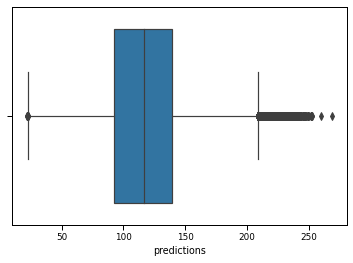

In [54]:
#visualization of predictions 
#plt.plot(predictions.predictions)

sns.set_context("paper", font_scale=1)
sns.boxplot(x = 'predictions', data = predictions)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

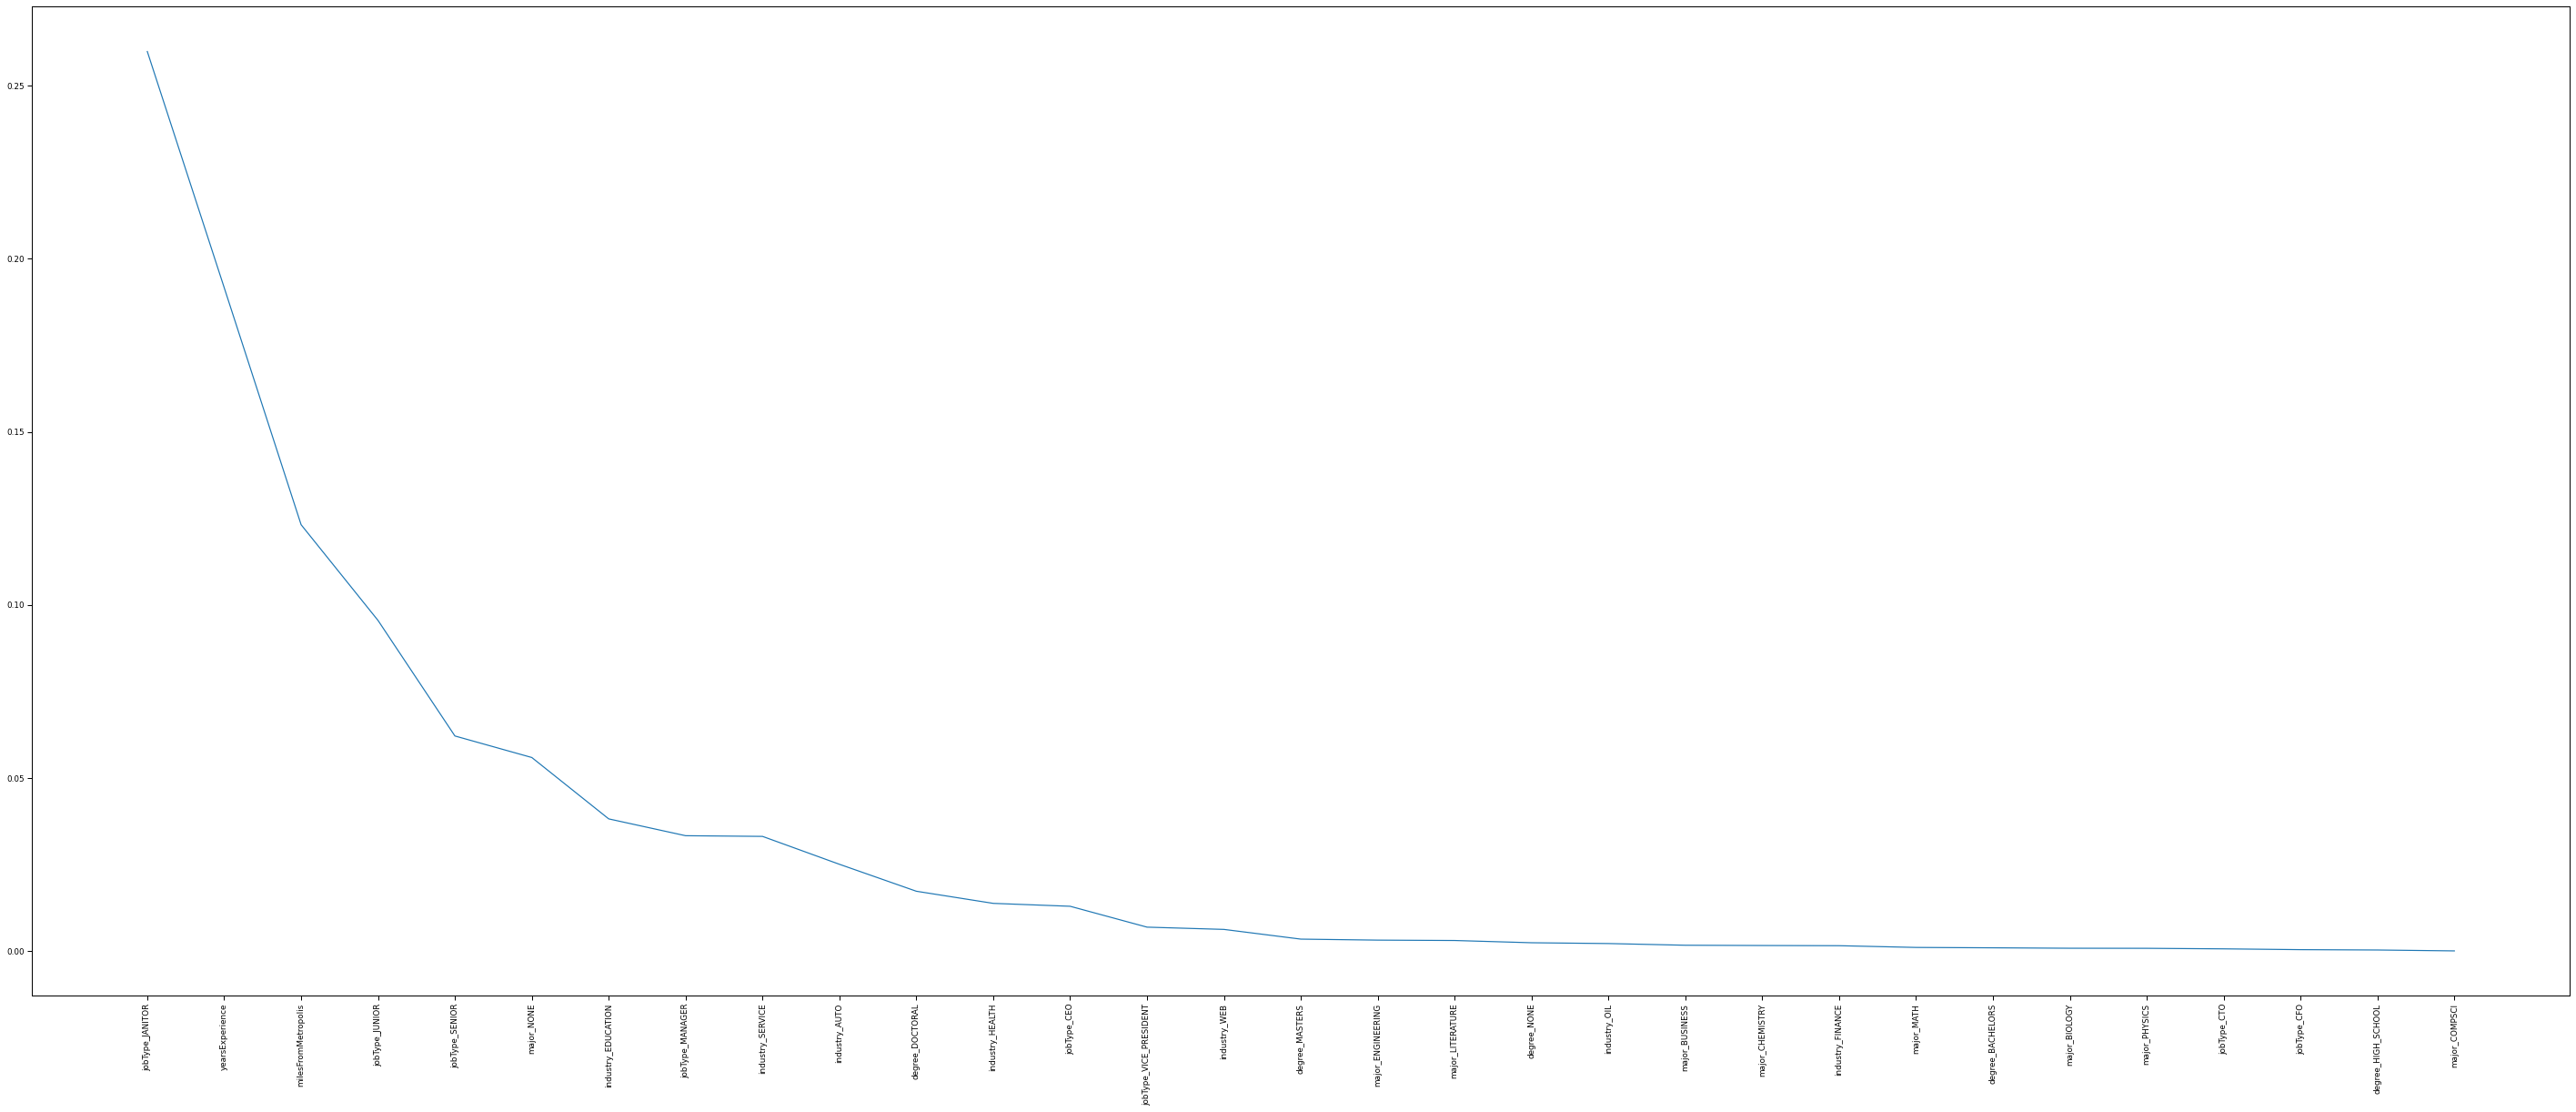

In [61]:
#getting feature importances
sns.set_context("paper", font_scale=1)
col_sorted_by_importance=np.flip(GBreg.feature_importances_.argsort())
feat_imp=pd.DataFrame({
    'cols':x.columns[col_sorted_by_importance],
    'imps':GBreg.feature_importances_[col_sorted_by_importance]
})

plt.figure(figsize = (50, 20)) 
plt.plot('cols','imps', data=feat_imp)
plt.xticks(rotation=90)
plt.show

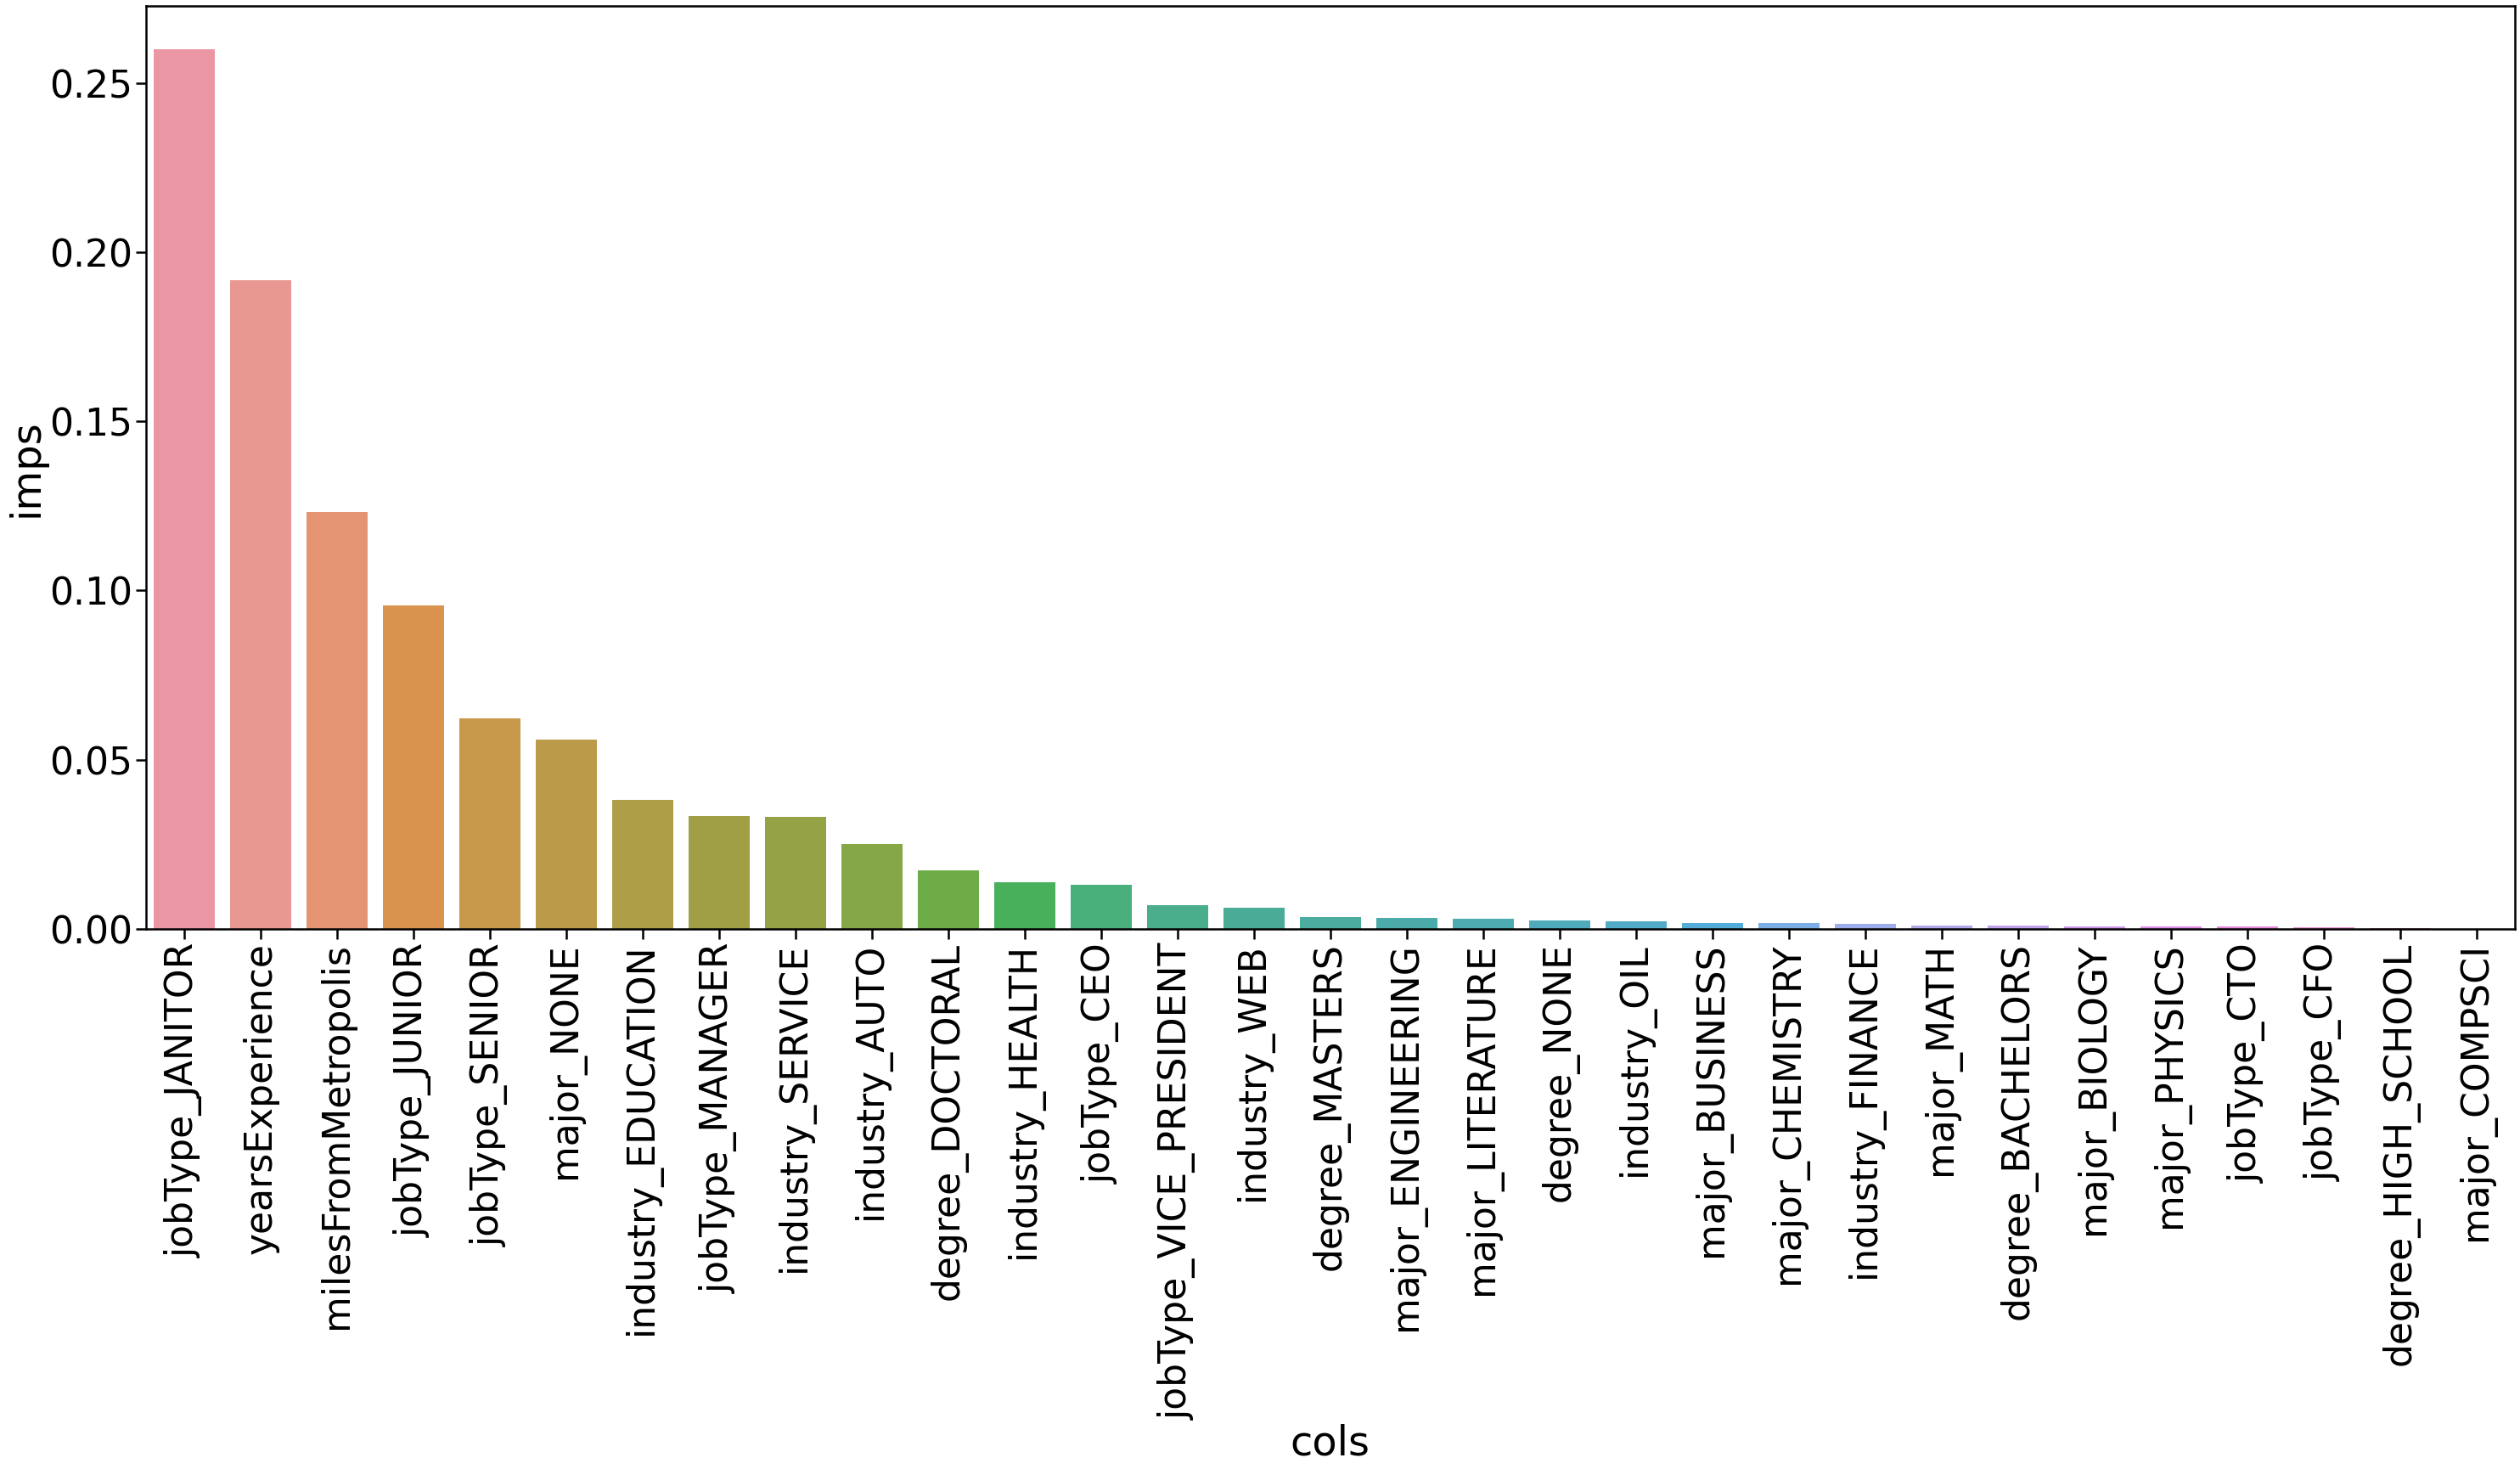

In [ ]:
#visualizing feature importances
#sns.set_context("poster", font_scale=2)
plt.figure(figsize = (50, 20)) 
sns.barplot(x = 'cols', y = 'imps', data = feat_imp)
plt.xticks(rotation=90)
plt.show()